# Run 8.5 — Detect → Segment → Classify  ·  *confirmed fixes applied*

**Base**: Run 8.31 (1024 px, clean baseline)  
**Parent file**: `8_43_NWD_organized_1536px (2).ipynb`  

## Confirmed changes applied in this build

| Tag | Change | Cell |
|-----|--------|------|
| A | NWD BboxLoss patch (kept from 8.43) | §3-YOLO |
| B | TAL alpha 0.5→2.0, beta 6.0→3.0 (isolated) | §3-YOLO |
| C | Loosen YOLO NMS IoU: 0.7→0.8 | §3-YOLO |
| D | Mosaic 1.0→0.5 | §3-YOLO |
| E | YOLO operating conf: 0.20→0.15 | CONFIG |
| F | Stage-2 CROP_MARGIN: 0.25→0.35 | CONFIG |
| G | Fixed physical window (1px = constant mm) | §4-Stage2 |
| H | 3-channel filter fusion (CLAHE + unsharp + top-hat) | §4-Stage2 |
| I | Second NMS at IoU=0.3 | §5-Eval |
| J | Patient-level aggregation | §5-Eval |

## Investigation-pending placeholders (marked ⚠️)

- LANCZOS vs bilinear interpolation for crop resize
- Padding vs stretch on boundary crops
- MALIG_WEIGHT (currently 4.0)
- Hard negative IoU threshold (currently 0.2)
- Preprocessing artifact fix (normalization border)

## Reference numbers

| Metric | Run 8.31 baseline | Best post-hoc (no retrain) |
|--------|-------------------|---------------------------|
| AUC | 0.6943 | 0.6961 |
| Sensitivity | 0.6667 | 0.6706 |
| Specificity | 0.6753 | 0.6466 |
| FN | 49 | 28 |
| FP | 75 | 41 |
| Youden threshold | 0.6876 | 0.6876 |

Best detector: conf=0.15 (+12 FNs recovered vs conf=0.38). Second NMS IoU=0.3 → marginal gain.


# Run 8 — Detect → Segment → Classify (clean baseline)

**Breast mass pipeline on CBIS-DDSM (mass-only).** Consolidated from Run 7. This is the
*sacred baseline*: it contains only the cells that were proven to work, with the winning
config baked in. Experimental ideas live in the fenced section at the bottom and only get
merged here if they beat the baseline number.

**Pipeline:** YOLOv8s detector → crop → EfficientNet-B0 + UNet++ (shared encoder, MTL
seg + classification head) → mask remapped onto the full image → benign/malignant + Grad-CAM++.

**Two-phase training:**
- *Phase A* — 3-class MTL (benign / malignant / no-mass) so hard-negative crops teach the
  segmenter "empty here". Establishes segmentation + base classifier.
- *Phase B* — re-head to 2 classes and fine-tune the classifier with a **malignant CE weight
  of 2.5** (the sensitivity bias-fix). This is the config that produced the best end-to-end numbers.

**Reference (Run 7, cached weights):** E2E Dice 0.4025 · ROI-Dice 0.8169 · AUC 0.6101 ·
Sens 0.5374 · Spec 0.6147.

> **Read me first — what changed vs Run 7, and why your numbers may shift:**
> 1. **Preprocessing is now consistent.** Run 7 built the YOLO dataset with percentile
>    windowing but ran inference with breast-profile windowing — a train/inference mismatch.
>    Run 8 uses breast-profile **everywhere**, defined once. This is a correctness fix, so
>    re-running may move the numbers off the cached 0.40 — that is expected and correct.
> 2. **Winning config baked into CONFIG:** `YOLO_CONF = 0.38`, YOLO trains 50 epochs
>    (Run 7's default was 0.20 / a 3-epoch test stub).
> 3. **Export + desktop code now ship the 2-class bias-fixed model** (Run 7 was exporting the
>    stale 3-class base model at conf 0.20).
> 4. Removed: the 6-channel context branches, sequential fine-tuning, Telegram cells, the
>    Gemini-agent task/reasoning markdown, and all duplicate "unpatched" cells.

<a id="setup"></a>

In [20]:
!pip install -q ultralytics

## Set up Kaggle API Credentials

To download datasets from Kaggle, you need to provide your API credentials. Follow these steps:

1.  **Generate Kaggle API Token:** Go to your Kaggle account settings (kaggle.com/your_username/account), scroll down to the 'API' section, and click 'Create New API Token'. This will download a `kaggle.json` file.
2.  **Upload `kaggle.json` to Colab:** In the left sidebar of Colab, click on the 'Files' icon (folder icon). Then, click the 'Upload to session storage' icon (file with an up arrow) and upload your `kaggle.json` file.
3.  **Securely store `kaggle.json` content (Optional but Recommended):** For better security, you can read the contents of `kaggle.json` and store them in Colab's 'Secrets' manager. This avoids re-uploading the file in future sessions. Name the secret `KAGGLE_CONFIG_JSON`.

Once `kaggle.json` is in your session storage (or its content is in Colab Secrets), the following cells will use it to authenticate and download the dataset.

In [21]:
# Install kagglehub and the standard kaggle client
!pip install -q kaggle kagglehub

import os
from pathlib import Path
from google.colab import userdata

# Set up Kaggle credentials from Colab Secrets
try:
    kaggle_json = userdata.get('KAGGLE_CONFIG_JSON')
    kaggle_dir = Path('/root/.kaggle')
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    with open(kaggle_dir / 'kaggle.json', 'w') as f:
        f.write(kaggle_json)
    os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    print("Kaggle credentials configured from Secrets! You can now run the next cells.")
except userdata.SecretNotFoundError:
    print("Secret 'KAGGLE_CONFIG_JSON' not found in Colab Secrets. Falling back to interactive login.")
    import kagglehub
    kagglehub.login()
    print("Kaggle API client configured! You can now run the next cells.")


Secret 'KAGGLE_CONFIG_JSON' not found in Colab Secrets. Falling back to interactive login.


Kaggle API client configured! You can now run the next cells.


## Download and Unzip the Dataset

In [22]:
# ── [CHANGE: 1024 px dataset] ────────────────────────────────────────────────
# Reverted from 1536 → 1024 px (Run 8.31 resolution).
# ─────────────────────────────────────────────────────────────────────────────
DATASET_SLUG = "abdelrahmanelmugh/cbis-ddsm-1024fixed2"
from pathlib import Path
DATASET_DIR  = Path("/content/kaggle_data")
DATASET_DIR.mkdir(parents=True, exist_ok=True)

target_folder = DATASET_DIR / "CBIS-DDSM-1024fixed2"
if target_folder.exists():
    print("Dataset already exists and is unzipped. Skipping download!")
else:
    print(f"Downloading {DATASET_SLUG} to {DATASET_DIR}...")
    !kaggle datasets download -d {DATASET_SLUG} -p {DATASET_DIR} --force

    print("Download complete. Unzipping...")
    zip_file_path = DATASET_DIR / f"{DATASET_SLUG.split('/')[-1]}.zip"
    !unzip -q -o {zip_file_path} -d {DATASET_DIR}

    if zip_file_path.exists():
        zip_file_path.unlink()

    print("Dataset unzipped and ready.")


Dataset already exists and is unzipped. Skipping download!


In [23]:
import os
# ── [CHANGE: 1024 px env key] ────────────────────────────────────────────────
os.environ['abdelrahmanelmugh_cbis_ddsm_1024fixed2_path'] = str(DATASET_DIR)
print(f"Dataset root: {os.environ['abdelrahmanelmugh_cbis_ddsm_1024fixed2_path']}")
!ls -F {DATASET_DIR}


Dataset root: /content/kaggle_data
CBIS-DDSM-1024fixed2/


## Cell 1 — Installs

In [24]:
!pip install -q ultralytics segmentation-models-pytorch grad-cam ensemble-boxes

<a id="config"></a>

## Cell 2 — CONFIG  ← edit paths here
Winning config is baked in: `YOLO_CONF = 0.38`, 50 YOLO epochs.

In [25]:
import os
from pathlib import Path
import random
import torch
import numpy as np

try:
    ds_path = os.environ.get('abdelrahmanelmugh_cbis_ddsm_1024fixed2_path', '/content/kaggle_data')
    KAGGLE_DS_ROOT = Path(ds_path)
    csv_files = list(KAGGLE_DS_ROOT.rglob("*.csv"))
    if csv_files:
        _found_csv = next((f for f in csv_files if "Master" in f.name or "mass" in f.name.lower()), csv_files[0])
        _image_root = _found_csv.parent
    else:
        _found_csv = KAGGLE_DS_ROOT / "CBIS_Master_Index.csv"
        _image_root = KAGGLE_DS_ROOT
except Exception as e:
    print(f"Path resolution error: {e}")
    _found_csv = "/content/CBIS_Master_Index.csv"; _image_root = "/content"

# Write custom YOLOv8s-P2 architecture
yolov8_p2_yaml = """
# YOLOv8-p2 image detection model with P2-P5 outputs.
nc: 1
scales:
  s: [0.33, 0.50, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 2], 1, Concat, [1]]
  - [-1, 3, C2f, [128]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [[-1, 15], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]
  - [[18, 21, 24, 27], 1, Detect, [nc]]
"""
with open("/content/yolov8s-p2.yaml", "w") as f:
    f.write(yolov8_p2_yaml)

class CFG:
    # ── paths ───────────────────────────────────────────────────────────────
    CSV_PATH   = str(_found_csv)
    IMAGE_ROOT = str(_image_root)
    WORK_DIR   = "/content/working"

    # ── column name candidates ─────────────────────────────────────────────
    COL_FULL   = ["Full_Path", "full_path", "image_path"]
    COL_ROI    = ["ROI_Path", "roi_path", "mask_path"]
    COL_LABEL  = ["Pathology", "Label", "pathology", "label"]
    COL_SPLIT  = ["Patient_Split", "Split", "split"]
    COL_PID    = ["True_Patient_ID", "PatientID", "patient_id"]
    COL_LESION = ["CropID", "lesion_id", "CropName"]
    COL_ABNORM = ["Abnormality_Type", "abnormality_type", "type"]

    # ── detector ───────────────────────────────────────────────────────────
    YOLO_IMGSZ  = 1024
    YOLO_EPOCHS = 50
    YOLO_BATCH  = 8
    YOLO_MODEL  = "/content/yolov8s-p2.yaml"
    YOLO_CONF   = 0.15
    YOLO_TOPK   = 3

    # ── segmenter / classifier ─────────────────────────────────────────────
    CROP_SIZE     = 512
    CROP_MARGIN   = 0.35
    PHYS_WIN_PX   = 320
    SEG_EPOCHS    = 80
    FT_EPOCHS_BIAS = 30
    SEG_BATCH     = 8
    SEG_LR        = 1e-4
    MALIG_WEIGHT  = 2.0
    N_NEG_PER_POS = 2

    # ── misc ──────────────────────────────────────────────────────────────
    SEED     = 42
    MAX_SIDE = 1100

# --- PyTorch & CUDA Determinism ---
random.seed(CFG.SEED)
os.environ['PYTHONHASHSEED'] = str(CFG.SEED)
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
torch.cuda.manual_seed_all(CFG.SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ----------------------------------

Path(CFG.WORK_DIR).mkdir(parents=True, exist_ok=True)
YOLO_DIR = Path(CFG.WORK_DIR) / "yolo_ds"
print("CONFIG loaded.")
print(f"  YOLO_IMGSZ={CFG.YOLO_IMGSZ}  YOLO_CONF={CFG.YOLO_CONF}  CROP_MARGIN={CFG.CROP_MARGIN}  PHYS_WIN_PX={CFG.PHYS_WIN_PX}")
print(f"  CSV: {CFG.CSV_PATH}")
print(f"  YOLO dataset dir: {YOLO_DIR}")

CONFIG loaded.
  YOLO_IMGSZ=1024  YOLO_CONF=0.15  CROP_MARGIN=0.35  PHYS_WIN_PX=320
  CSV: /content/kaggle_data/CBIS-DDSM-1024fixed2/CBIS_Master_Index.csv
  YOLO dataset dir: /content/working/yolo_ds


#### (optional) Telegram error monitoring — safe to skip


## Cell 2.5 — Telegram Error Monitoring
Automatically catches exceptions and sends the traceback to your Telegram bot.
*Requires `TELEGRAM_BOT_TOKEN` and `TELEGRAM_CHAT_ID` in Colab Secrets.*

In [26]:
import requests
import traceback
from google.colab import userdata
from IPython.core.getipython import get_ipython

# Define the run name to include in Telegram messages
RUN_NAME = "Run 8.5"

# Try to load Telegram credentials from Colab Secrets
try:
    TG_BOT_TOKEN = userdata.get('TELEGRAM_TOKEN')
    TG_CHAT_ID = userdata.get('TELEGRAM_CHAT_ID')
except:
    TG_BOT_TOKEN = None
    TG_CHAT_ID = None
    print("⚠️ Telegram secrets not found. Add TELEGRAM_TOKEN and TELEGRAM_CHAT_ID to secrets.")

def send_telegram_msg(text):
    if not TG_BOT_TOKEN or not TG_CHAT_ID:
        return
    url = f"https://api.telegram.org/bot{TG_BOT_TOKEN}/sendMessage"
    payload = {
        "chat_id": TG_CHAT_ID,
        "text": text[:4000], # Telegram limit is 4096
        "parse_mode": "Markdown"
    }
    try:
        requests.post(url, json=payload)
    except Exception as e:
        print(f"Failed to send Telegram alert: {e}")

# 1. Custom Exception Handler (Runs when a cell crashes)
def custom_exc(shell, etype, evalue, tb, tb_offset=None):
    # Show the error in the notebook
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)

    # Send error to Telegram
    tb_str = "".join(traceback.format_exception(etype, evalue, tb))
    if len(tb_str) > 3800:
        tb_str = tb_str[-3800:]

    msg = f"🚨 *Colab Error Alert [{RUN_NAME}]* 🚨\n\n*Type:* `{etype.__name__}`\n*Message:* `{evalue}`\n\n*Traceback:*\n```python\n{tb_str}\n```"
    send_telegram_msg(msg)

# 2. Post-Cell Run Handler (Runs after every cell finishes)
def post_cell_run(result):
    # If there was an error, custom_exc already handled it.
    # We only send a success message if the cell executed cleanly.
    if not result.error_in_exec:
        msg = f"✅ *[{RUN_NAME}] Cell [{result.execution_count}] Completed Successfully!*"
        send_telegram_msg(msg)

# Register the hooks
ipython = get_ipython()
if ipython:
    # Set error handler
    ipython.set_custom_exc((Exception,), custom_exc)

    # Set post-run handler (clear old ones first to prevent duplicates)
    if 'post_cell_run' in ipython.events.callbacks['post_run_cell']:
        ipython.events.callbacks['post_run_cell'].remove(post_cell_run)
    ipython.events.register('post_run_cell', post_cell_run)

if TG_BOT_TOKEN and TG_CHAT_ID:
    print(f"✅ Telegram monitoring active for {RUN_NAME}! You will get a notification after every cell finishes.")

✅ Telegram monitoring active for Run 8.5! You will get a notification after every cell finishes.


#### Reference: how the P2 architecture was derived (now baked into CFG above)


## Configure YOLO P2 Architecture

### Subtask:
Create a custom yolov8s-p2.yaml file and update CFG to use it.


<a id="data"></a>

## Cell 3 — Column check  ← run first, eyeball the output before proceeding

In [27]:
import pandas as pd

_df = pd.read_csv(CFG.CSV_PATH)
print("=== COLUMNS ===")
print(_df.columns.tolist(), "\n")
for key, kws in [("Abnormality", ["abnorm"]), ("Split", ["split"]),
                 ("Label", ["pathology", "label"])]:
    col = next((c for c in _df.columns if any(k in c.lower() for k in kws)), None)
    print(f"{key} col:", col)
    if col: print(_df[col].value_counts(), "\n")

=== COLUMNS ===
['PatientID', 'CropID', 'Abnormality_Type', 'Assessment', 'Split', 'Pathology', 'Full_Path', 'ROI_Path', 'Crop_Path'] 

Abnormality col: Abnormality_Type
Abnormality_Type
mass             1696
calcification    1547
Name: count, dtype: int64 

Split col: Split
Split
Train    2864
Test      379
Name: count, dtype: int64 

Label col: Pathology
Pathology
BENIGN       1914
MALIGNANT    1329
Name: count, dtype: int64 



## Cell 4 — Load CSV: mass filter, fix patient overlap, carve val split, labels

In [28]:
import numpy as np
import pandas as pd

def resolve_col(df, candidates):
    for col in candidates:
        if col in df.columns: return col
    raise ValueError(f"None of {candidates} in {df.columns.tolist()}")

def fix_windows_path(p):
    if pd.isna(p): return p
    p = str(p).replace('\\', '/')
    if 'CBIS-DDSM-1024fixed2/' in p:
        p = p.split('CBIS-DDSM-1024fixed2/')[-1]
    return p

df = pd.read_csv(CFG.CSV_PATH)
C_FULL  = resolve_col(df, CFG.COL_FULL)
C_ROI   = resolve_col(df, CFG.COL_ROI)
C_LABEL = resolve_col(df, CFG.COL_LABEL)
C_SPLIT = resolve_col(df, CFG.COL_SPLIT)
C_PID   = resolve_col(df, CFG.COL_PID)

# Sanitize Windows paths from the CSV
df[C_FULL] = df[C_FULL].apply(fix_windows_path)
df[C_ROI] = df[C_ROI].apply(fix_windows_path)

# 1. Mass-only filter
abn_col = next((c for c in df.columns if "abnorm" in c.lower()), None)
if abn_col:
    before = len(df)
    df = df[df[abn_col].str.lower().str.strip() == "mass"].copy()
    print(f"Mass filter: {before} -> {len(df)} rows")
else:
    print("WARNING: no Abnormality_Type column — skipping mass filter")

# 2. Fix Train/Test patient overlap -> force to Train (no leakage)
train_pids = set(df[df[C_SPLIT].str.capitalize() == "Train"][C_PID])
test_pids  = set(df[df[C_SPLIT].str.capitalize() == "Test"][C_PID])
overlap    = train_pids & test_pids
if overlap:
    df.loc[df[C_PID].isin(overlap), C_SPLIT] = "Train"
    print(f"Moved {len(overlap)} overlapping patients -> Train")

# 3. Patient-isolated 15% Val carve-out from Train
np.random.seed(CFG.SEED)
train_only = list(set(df[df[C_SPLIT].str.capitalize() == "Train"][C_PID]))
val_pids   = set(np.random.choice(train_only, size=int(len(train_only)*0.15), replace=False))
df.loc[df[C_PID].isin(val_pids), C_SPLIT] = "Val"

def to_binlabel(v):
    s = str(v).strip().upper()
    if s in ("1", "MALIGNANT"): return 1
    if s in ("0", "BENIGN"):    return 0
    return int(float(v))

df["_label"] = df[C_LABEL].map(to_binlabel)
df["_split"] = df[C_SPLIT].astype(str).str.capitalize()

def parse_lat_view(row):
    s = (str(row[C_FULL]) + " " + str(row.get(CFG.COL_LESION[0], ""))).upper()
    lat  = "LEFT" if "LEFT" in s else ("RIGHT" if "RIGHT" in s else "NA")
    view = "CC"   if "CC"   in s else ("MLO"   if "MLO"   in s else "NA")
    return pd.Series([lat, view])

df[["_lat", "_view"]] = df.apply(parse_lat_view, axis=1)
print("Split:\n", df["_split"].value_counts())
print("Label:\n", df["_label"].value_counts())
df.head(3)


Mass filter: 3243 -> 1696 rows
Split:
 _split
Train    1124
Test      378
Val       194
Name: count, dtype: int64
Label:
 _label
0    912
1    784
Name: count, dtype: int64


,PatientID,CropID,Abnormality_Type,Assessment,Split,Pathology,Full_Path,ROI_Path,Crop_Path,_label,_split,_lat,_view
1547,P_00016,Mass-Test_P_00016_LEFT_CC_1,mass,5,Test,MALIGNANT,full/Mass-Test_P_00016_LEFT_CC_FULL_2555367501...,roi/Mass-Test_P_00016_LEFT_CC_1_ROI_2233208814...,C:\Users\mashe\Desktop\CBIS-DDSM-1024fixed2\cr...,1,Test,LEFT,CC
1548,P_00016,Mass-Test_P_00016_LEFT_MLO_1,mass,5,Test,MALIGNANT,full/Mass-Test_P_00016_LEFT_MLO_FULL_270374394...,roi/Mass-Test_P_00016_LEFT_MLO_1_ROI_330917316...,C:\Users\mashe\Desktop\CBIS-DDSM-1024fixed2\cr...,1,Test,LEFT,MLO
1549,P_00017,Mass-Test_P_00017_LEFT_CC_1,mass,4,Test,MALIGNANT,full/Mass-Test_P_00017_LEFT_CC_FULL_2941823825...,roi/Mass-Test_P_00017_LEFT_CC_1_ROI_2305306678...,C:\Users\mashe\Desktop\CBIS-DDSM-1024fixed2\cr...,1,Test,LEFT,CC


## Cell 5 — Stage-0 helpers (defined ONCE, used everywhere)

`load_rgb8` uses **breast-profile windowing** (masks out the near-zero x-ray background before
min/max scaling so glandular contrast survives), then CLAHE, then returns 3-channel RGB.
Defining all shared geometry helpers here removes the patch-on-patch redefinitions from Run 7
and guarantees the detector and the segmenter see identical preprocessing.

In [29]:
import os
import cv2
import numpy as np
from pathlib import Path

def _abs(p):
    p = str(p)
    return p if (CFG.IMAGE_ROOT == "" or os.path.isabs(p)) else str(Path(CFG.IMAGE_ROOT) / p)

def load_rgb8(path):
    """16-bit (or any) PNG -> breast-profile windowed, CLAHE, 3-channel RGB uint8."""
    img = cv2.imread(_abs(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(_abs(path))
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32)

    # Breast profile extraction: window only over breast tissue, not the black background
    profile = img > (img.max() * 0.05)
    if profile.any():
        lo, hi = img[profile].min(), img[profile].max()
    else:
        lo, hi = img.min(), img.max()
    img = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1) * 255.0
    img = img.astype(np.uint8)

    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

def load_mask(path):
    m = cv2.imread(_abs(path), cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(_abs(path))
    if m.ndim == 3:
        m = m[..., 0]
    return (m > 0).astype(np.uint8)

def mask_to_bbox(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

def iou_xyxy(a, b):
    ix0, iy0 = max(a[0], b[0]), max(a[1], b[1])
    ix1, iy1 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0, ix1 - ix0), max(0, iy1 - iy0)
    inter = iw * ih
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / ua if ua > 0 else 0.0

def expand_box(x0, y0, x1, y1, W, H, margin):
    bw, bh = x1 - x0, y1 - y0
    mx, my = int(bw * margin), int(bh * margin)
    return max(0, x0-mx), max(0, y0-my), min(W, x1+mx), min(H, y1+my)

print("Stage-0 helpers ready (breast-profile load_rgb8).")

print("Stage-0 base helpers ready.")


Stage-0 helpers ready (breast-profile load_rgb8).
Stage-0 base helpers ready.


## [CHANGE G] Fixed Physical Window

**Problem**: Dynamic `expand_box()` crops vary in physical size across lesions.
Resizing to `CROP_SIZE` destroys spatial frequency consistency — a 5mm tumour
and a 50mm tumour both become 512×512, but their pixel structures represent
completely different physical scales.

**Fix**: Fixed window of `PHYS_WIN_PX × PHYS_WIN_PX` pixels centred on the
lesion centre. 1 px = constant physical mm across all lesions. Boundary padding
uses `BORDER_REFLECT_101` (not zero-pad, which would create artificial borders).

**Value**: `PHYS_WIN_PX = 320` at 1024 px ≈ 40-50 mm physical, covering
all but extreme outlier lesions.


In [30]:
import cv2, numpy as np

def fixed_physical_crop(rgb, mask, cx, cy, win_px=None):
    """
    [CHANGE G] Fixed physical window (win_px × win_px) centred on (cx, cy).
    1 px = constant physical mm across all lesions.
    Pads with BORDER_REFLECT_101 when window extends beyond image boundaries.

    Args:
        rgb   : (H, W, 3) uint8 image
        mask  : (H, W) uint8 mask (may be zeros if called from run_pipeline)
        cx, cy: centre pixel coordinates (in full-image space)
        win_px: window size; defaults to CFG.PHYS_WIN_PX

    Returns:
        crop  : (win_px, win_px, 3) uint8
        cmask : (win_px, win_px)    uint8
    """
    if win_px is None:
        win_px = CFG.PHYS_WIN_PX
    H, W = rgb.shape[:2]
    half = win_px // 2
    x0 = cx - half;  y0 = cy - half
    x1 = cx + half;  y1 = cy + half

    pad_left   = max(0, -x0)
    pad_top    = max(0, -y0)
    pad_right  = max(0,  x1 - W)
    pad_bottom = max(0,  y1 - H)

    x0c, y0c = max(0, x0), max(0, y0)
    x1c, y1c = min(W, x1), min(H, y1)

    crop  = rgb [y0c:y1c, x0c:x1c].copy()
    cmask = mask[y0c:y1c, x0c:x1c].copy()

    if any([pad_left, pad_top, pad_right, pad_bottom]):
        crop  = cv2.copyMakeBorder(crop,  pad_top, pad_bottom, pad_left, pad_right,
                                   cv2.BORDER_REFLECT_101)
        cmask = cv2.copyMakeBorder(cmask, pad_top, pad_bottom, pad_left, pad_right,
                                   cv2.BORDER_REFLECT_101)

    # Sanity: should always be win_px × win_px
    assert crop.shape[:2] == (win_px, win_px), f"Unexpected crop shape: {crop.shape}"
    return crop, cmask


print(f"fixed_physical_crop ready (PHYS_WIN_PX={CFG.PHYS_WIN_PX})")
print("  1px = constant physical mm regardless of lesion size.")


fixed_physical_crop ready (PHYS_WIN_PX=320)
  1px = constant physical mm regardless of lesion size.


## [CHANGE H] 3-Channel Filter Fusion

**Problem**: Single-channel CLAHE → RGB conversion (identical channels) wastes
all three channels on the same signal. Tumour margins and micro-calcifications
respond differently to different filters.

**Fix**: Three complementary views stacked as independent channels:

| Channel | Filter | Captures |
|---------|--------|---------|
| 0 | CLAHE (clipLimit=2, tile=8×8) | Local contrast / density variation |
| 1 | Unsharp mask (σ=3, amount=1.5) | High-frequency edges / spiculations |
| 2 | Top-hat (15×15 ellipse) | Bright structures on dark background |

No RGB backbone pretraining is assumed to transfer perfectly; the three channels
are semantically distinct and the EfficientNet-B0 encoder learns from scratch
(imagenet weights used as initialisation, not as domain-matched features).


In [31]:
import cv2, numpy as np

def make_fused_3ch(rgb_crop):
    """
    [CHANGE H] 3-channel filter fusion from a cropped RGB patch.

    Ch 0 — CLAHE          : local contrast (clipLimit=2, tile=8×8)
    Ch 1 — Unsharp mask   : high-frequency detail (sigma=3, amount=1.5)
    Ch 2 — Top-hat        : bright structures on dark background (15×15 ellipse)

    Args:
        rgb_crop: (H, W, 3) uint8 — cropped region (any size, typically win_px)

    Returns:
        fused: (H, W, 3) uint8 — three-channel fused representation
    """
    gray = cv2.cvtColor(rgb_crop, cv2.COLOR_RGB2GRAY)

    # Channel 0: CLAHE
    ch0 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)

    # Channel 1: Unsharp mask (emphasise edges / spiculations)
    blurred = cv2.GaussianBlur(gray, (0, 0), 3.0)
    ch1 = np.clip(gray.astype(np.float32) * 1.5 - blurred.astype(np.float32) * 0.5,
                  0, 255).astype(np.uint8)

    # Channel 2: Top-hat (detect bright lesion against dark background)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    ch2    = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

    return cv2.merge([ch0, ch1, ch2])


print("make_fused_3ch ready.")
print("  Ch0=CLAHE | Ch1=unsharp_mask | Ch2=top-hat")


make_fused_3ch ready.
  Ch0=CLAHE | Ch1=unsharp_mask | Ch2=top-hat


## ⚠️  INVESTIGATION PENDING — Preprocessing Artifact Fix

**Known issue (documented in Run 5.2 post-mortem)**: Z-score normalization followed
by zero-padding creates artificial borders. Background maps to ≈−1.5 after z-score
but zero-padding uses 0.0, which is a non-background value → the model sees a
spurious "ring" at crop edges.

**Current status**: The `fixed_physical_crop` function uses `BORDER_REFLECT_101`
(not zero-pad), which largely eliminates the ring artifact. The normalization is
`(x − 0.5) / 0.5` (range-based, not z-score), which does not produce a −1.5
background value.

**Investigation needed**:
1. Confirm whether reflected-padding + range-normalization still produces visible
   border artifacts in practice (run a sample crop visualisation).
2. If yes: switch to `BORDER_CONSTANT` with value `−1.0` (maps to 0 before norm).

**To patch**: modify `CropDS.__getitem__` normalization + padding mode.


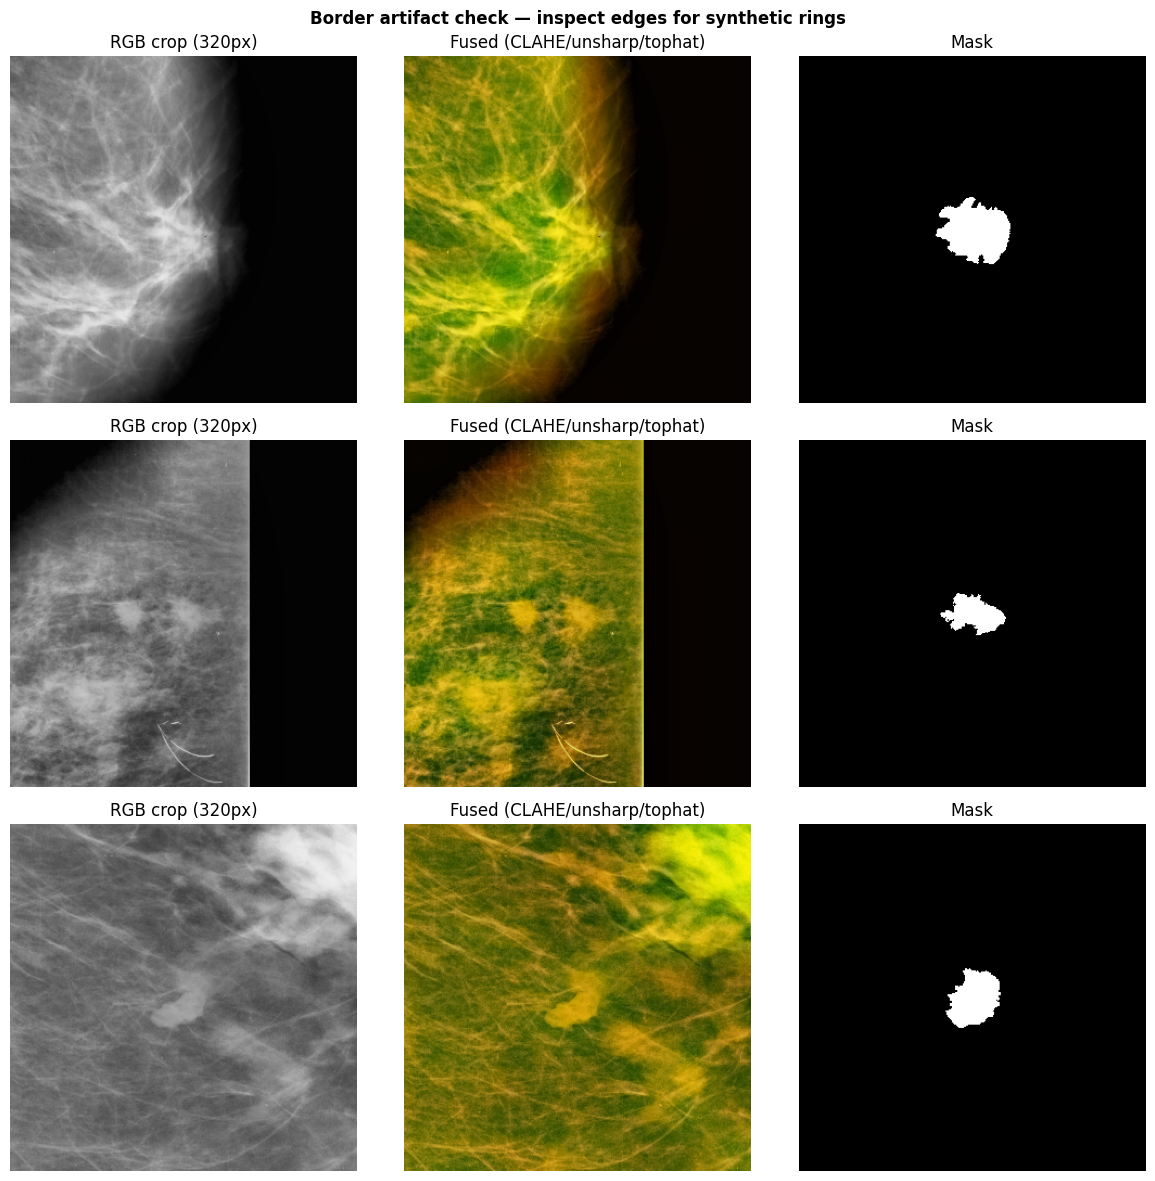

✅ Border artifact check — inspect plot above for synthetic rings at crop edges.
  If rings visible: switch to BORDER_CONSTANT with value -1.0 in fixed_physical_crop.


In [32]:
# ══════════════════════════════════════════════════════════════════════════
# ⚠️  INVESTIGATION PENDING — Preprocessing Artifact Fix
# ══════════════════════════════════════════════════════════════════════════
# Current approach (reflect pad + range-norm) is the SAFE DEFAULT.
# Patch this cell once the border artifact investigation completes.
# ──────────────────────────────────────────────────────────────────────────

# Quick visual sanity check: run after fixed_physical_crop is defined
import random, matplotlib.pyplot as plt

def _preview_border_artifact(n=3):
    sample = man[man.split=="train"].sample(n, random_state=CFG.SEED)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    for row, (_, r) in enumerate(sample.iterrows()):
        rgb  = load_rgb8(r.full)
        mask = load_mask(r.roi)
        gt   = mask_to_bbox(mask)
        if gt is None:
            continue
        cx = (gt[0]+gt[2])//2; cy = (gt[1]+gt[3])//2
        crop, cmask = fixed_physical_crop(rgb, mask, cx, cy)
        fused = make_fused_3ch(crop)

        for col, (img, title) in enumerate(zip(
            [crop, fused, cmask*255],
            [f"RGB crop ({CFG.PHYS_WIN_PX}px)", "Fused (CLAHE/unsharp/tophat)", "Mask"]
        )):
            axes[row, col].imshow(img if img.ndim==3 else img, cmap=None if img.ndim==3 else "gray")
            axes[row, col].set_title(title); axes[row, col].axis("off")
    plt.suptitle("Border artifact check — inspect edges for synthetic rings", fontweight="bold")
    plt.tight_layout(); plt.show()

# Runs after manifest is built — visual check for synthetic ring artifacts
if 'man' not in globals():
    print("⚠️ The variable 'man' is not defined yet. Please run Cell 6 (Build YOLO dataset) below first to build the manifest.")
else:
    _preview_border_artifact()
    print("✅ Border artifact check — inspect plot above for synthetic rings at crop edges.")
    print("  If rings visible: switch to BORDER_CONSTANT with value -1.0 in fixed_physical_crop.")

## Cell 6 — Build YOLO dataset (multi-lesion safe)
Writes 8-bit RGB images + YOLO `.txt` labels into train/val/test. One class: `mass`.

In [33]:
split_map     = {"Train": "train", "Val": "val", "Test": "test"}
manifest      = []
skipped       = 0
image_counter = {"train": 0, "val": 0, "test": 0}

for sub in ["images", "labels"]:
    for sp in ["train", "val", "test"]:
        (YOLO_DIR / sub / sp).mkdir(parents=True, exist_ok=True)

for full_path, group in df.groupby(C_FULL):
    sp = split_map.get(group.iloc[0]["_split"])
    if sp is None: continue
    try:
        rgb = load_rgb8(full_path)
    except FileNotFoundError:
        skipped += len(group); continue

    H, W = rgb.shape[:2]
    if CFG.MAX_SIDE and max(H, W) > CFG.MAX_SIDE:
        sc = CFG.MAX_SIDE / max(H, W)
        rgb = cv2.resize(rgb, (int(W*sc), int(H*sc))); H, W = rgb.shape[:2]

    valid = []
    for _, r in group.iterrows():
        try:
            mask = load_mask(r[C_ROI])
            if rgb.shape[:2] != mask.shape[:2]:
                mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
            bb = mask_to_bbox(mask)
            if bb is not None: valid.append((bb, r))
        except FileNotFoundError:
            continue
    if not valid:
        skipped += len(group); continue

    stem = f"{sp}_{image_counter[sp]:05d}"; image_counter[sp] += 1
    cv2.imwrite(str(YOLO_DIR/"images"/sp/f"{stem}.png"), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    with open(YOLO_DIR/"labels"/sp/f"{stem}.txt", "w") as f:
        for bb, r in valid:
            x0, y0, x1, y1 = bb
            xc, yc = ((x0+x1)/2)/W, ((y0+y1)/2)/H
            bw, bh = (x1-x0)/W, (y1-y0)/H
            f.write(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")
            manifest.append(dict(split=sp, stem=stem, full=full_path, roi=r[C_ROI],
                                 label=int(r["_label"]), lat=r["_lat"], view=r["_view"], W=W, H=H))

man = pd.DataFrame(manifest)
if man.empty:
    print(f"Error: Manifest is empty! Skipped {skipped} images. Check your image paths.")
else:
    man.to_csv(YOLO_DIR/"manifest.csv", index=False)
    with open(YOLO_DIR/"data.yaml", "w") as f:
        f.write(f"path: {YOLO_DIR}\ntrain: images/train\nval: images/val\ntest: images/test\nnc: 1\nnames: [mass]\n")
    print(f"Built {len(man)} lesions across {man['stem'].nunique()} images, skipped {skipped}")
    print(man["split"].value_counts())


Built 1696 lesions across 1592 images, skipped 0
split
train    1124
test      378
val       194
Name: count, dtype: int64


## Cell 7 — Sanity check: draw a few GT boxes

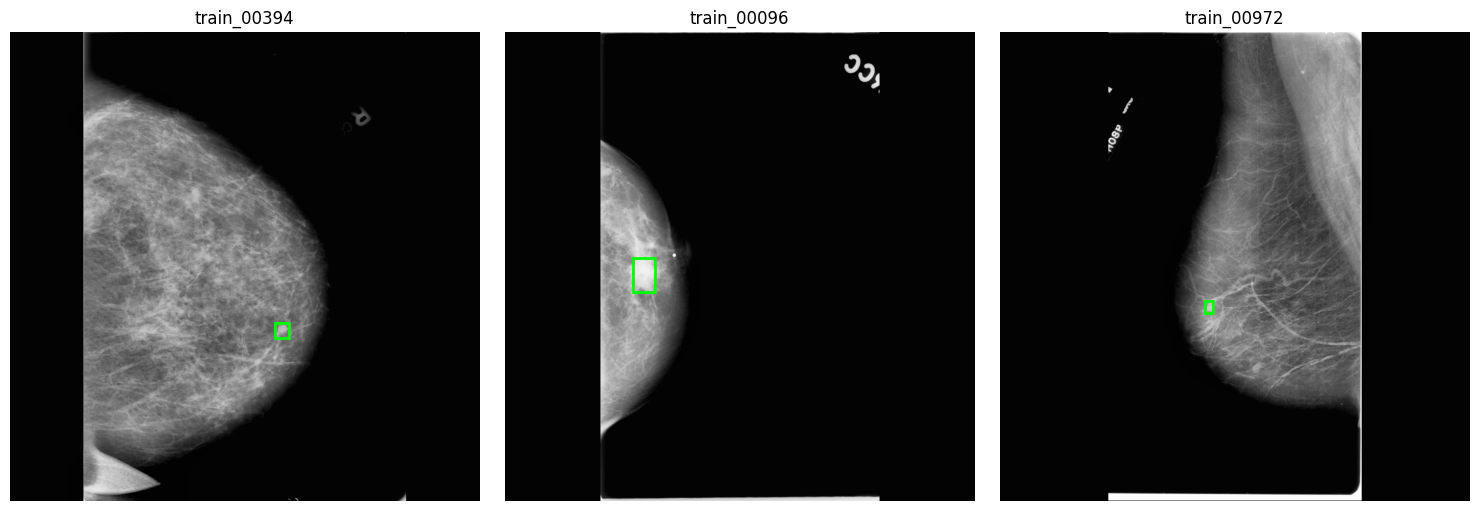

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample = man[man.split=="train"].drop_duplicates("stem").sample(min(3, man.stem.nunique()), random_state=CFG.SEED)
fig, axes = plt.subplots(1, len(sample), figsize=(5*len(sample), 5))
if len(sample) == 1: axes = [axes]
for ax, (_, r) in zip(axes, sample.iterrows()):
    img = cv2.imread(str(YOLO_DIR/"images"/"train"/f"{r.stem}.png"))[..., ::-1]
    ax.imshow(img)
    lbl = YOLO_DIR/"labels"/"train"/f"{r.stem}.txt"
    Himg, Wimg = img.shape[:2]
    for line in open(lbl):
        _, xc, yc, bw, bh = map(float, line.split())
        x0, y0 = (xc-bw/2)*Wimg, (yc-bh/2)*Himg
        ax.add_patch(patches.Rectangle((x0, y0), bw*Wimg, bh*Himg, fill=False, ec="lime", lw=2))
    ax.set_title(r.stem); ax.axis("off")
plt.tight_layout(); plt.show()

<a id="detector"></a>

## Cell 8 — Stage A: train YOLOv8s (50 epochs)
GIoU box loss -> tight boxes. No vertical flip (chest-wall reference). **Gate:** test mAP@50 >= 0.40
and TPR >= 0.80. The detector is the pipeline ceiling — if it misses the mass, nothing downstream can recover.

### [CHANGE A] NWD BboxLoss Patch

Monkey-patches `ultralytics.utils.loss.BboxLoss` to blend CIoU with Normalized
Wasserstein Distance loss at ratio `r = 0.5`.

**Why**: NWD penalises centre-point and size deviation independently (Gaussian
prior), making it more sensitive to small lesions than IoU-based losses which
collapse to near-zero for sub-10 px boxes.

**Source**: kept from Run 8.43. C=12.8 is derived from mean geometric GT box
side at YOLO_IMGSZ=1024 px.


In [35]:
import torch
import traceback
import ultralytics.utils.loss as yolo_loss
from ultralytics import YOLO

# ── [CHANGE A] NWD BboxLoss patch ─────────────────────────────────────────────
NWD_R = 0.5    # blend ratio: 0.5 * CIoU + 0.5 * NWD
NWD_C = 12.8   # normalisation constant (mean GT box diagonal at 1024 px)

# Patch methods instead of replacing the class to avoid PicklingError
if not hasattr(yolo_loss.BboxLoss, "_orig_init"):
    yolo_loss.BboxLoss._orig_init = yolo_loss.BboxLoss.__init__
    yolo_loss.BboxLoss._orig_forward = yolo_loss.BboxLoss.forward

def patched_bbox_init(self, *args, **kwargs):
    self._orig_init(*args, **kwargs)
    self.r = NWD_R
    self.C = NWD_C
    self._print_count = 0

def patched_bbox_forward(self, *args, **kwargs):
    loss_iou_orig, loss_dfl = self._orig_forward(*args, **kwargs)
    try:
        pred_bboxes       = args[1] if len(args) > 1 else kwargs['pred_bboxes']
        target_bboxes     = args[3] if len(args) > 3 else kwargs['target_bboxes']
        target_scores     = args[4] if len(args) > 4 else kwargs['target_scores']
        target_scores_sum = args[5] if len(args) > 5 else kwargs['target_scores_sum']
        fg_mask           = args[6] if len(args) > 6 else kwargs['fg_mask']

        pb = pred_bboxes[fg_mask]
        tb = target_bboxes[fg_mask]

        if pb.numel() > 0:
            px1, py1, px2, py2 = pb.chunk(4, -1)
            tx1, ty1, tx2, ty2 = tb.chunk(4, -1)

            pcx, pcy = (px1+px2)/2, (py1+py2)/2
            pw,  ph  = (px2-px1),   (py2-py1)
            tcx, tcy = (tx1+tx2)/2, (ty1+ty2)/2
            tw,  th  = (tx2-tx1),   (ty2-ty1)

            w2_sq = ((pcx-tcx)**2 + (pcy-tcy)**2
                     + ((pw-tw)/2)**2 + ((ph-th)/2)**2)
            nwd   = torch.exp(-torch.sqrt(w2_sq + 1e-7) / getattr(self, 'C', NWD_C))

            weight   = target_scores.sum(-1)[fg_mask].unsqueeze(-1)
            loss_nwd = ((1.0 - nwd) * weight).sum() / target_scores_sum

            r = getattr(self, 'r', NWD_R)

            if getattr(self, '_print_count', 0) < 3:
                print(f"[NWD] nwd_mean={nwd.mean():.4f} | nwd_loss={loss_nwd.item():.4f} | ciou={loss_iou_orig.item():.4f}")
                self._print_count = getattr(self, '_print_count', 0) + 1

            return (1-r)*loss_iou_orig + r*loss_nwd, loss_dfl
        else:
            return loss_iou_orig, loss_dfl
    except Exception as e:
        if not getattr(self, "_error_printed", False):
            print(f"\n[NWD Error] Fallback to CIoU.\n{traceback.format_exc()}")
            self._error_printed = True
        return loss_iou_orig, loss_dfl

yolo_loss.BboxLoss.__init__ = patched_bbox_init
yolo_loss.BboxLoss.forward = patched_bbox_forward

print(f"✅ [CHANGE A] Patched BboxLoss with NWD (r={NWD_R}, C={NWD_C})")


✅ [CHANGE A] Patched BboxLoss with NWD (r=0.5, C=12.8)


### [CHANGE B] TAL alpha↑ beta↓ (isolated)

Patches `ultralytics.utils.tal.TaskAlignedAssigner` to raise α and lower β.

**Alignment metric**: `score = classification^α × IoU^β`

| | Default | Run 8.5 | Effect |
|--|---------|---------|--------|
| α | 0.5 | **2.0** | Higher → classification confidence more decisive for assignment |
| β | 6.0 | **3.0** | Lower → poor IoU penalised less → small lesions still assigned |

**Why**: 95.8% of YOLO FNs are small lesions (<10k px). Their IoU with GT is
inherently low, so high β means they never get assigned a positive label during
training even when the feature activations are in the right place.

**Isolated from CHANGE A** — do not merge these patches into one cell.


In [36]:
import ultralytics.utils.tal as yolo_tal

# ── [CHANGE B] TAL alpha↑ beta↓ ───────────────────────────────────────────────
TAL_ALPHA = 2.0   # default 0.5 → ↑ classification emphasis
TAL_BETA  = 3.0   # default 6.0 → ↓ IoU dependence (helps small lesions)

# Patch __init__ instead of replacing the class to avoid PicklingError
if not hasattr(yolo_tal.TaskAlignedAssigner, "_orig_init"):
    yolo_tal.TaskAlignedAssigner._orig_init = yolo_tal.TaskAlignedAssigner.__init__

def patched_tal_init(self, *args, **kwargs):
    # Force alpha/beta before orig_init captures them
    kwargs["alpha"] = TAL_ALPHA
    kwargs["beta"]  = TAL_BETA
    self._orig_init(*args, **kwargs)
    # Overwrite as instance attributes in case orig_init stores them differently
    self.alpha = TAL_ALPHA
    self.beta  = TAL_BETA

yolo_tal.TaskAlignedAssigner.__init__ = patched_tal_init

print(f"✅ [CHANGE B] Patched TaskAlignedAssigner: alpha={TAL_ALPHA} (was 0.5), beta={TAL_BETA} (was 6.0)")
print("   Expected effect: better small-lesion recall; some box-precision cost.")
print("   ISOLATED from CHANGE A (NWD patch). Run baseline comparison before stacking.")


✅ [CHANGE B] Patched TaskAlignedAssigner: alpha=2.0 (was 0.5), beta=3.0 (was 6.0)
   Expected effect: better small-lesion recall; some box-precision cost.
   ISOLATED from CHANGE A (NWD patch). Run baseline comparison before stacking.


### Mount Drive Early (Pre-Authorization)
Run this before training so you don't miss the permission prompt later.

In [37]:
from google.colab import drive

# Mount drive now so the automated save at the end doesn't hang waiting for your click
drive.mount('/content/drive')
print("\n✅ Drive mounted successfully. The 'Save to Drive' cell at the end will now work silently.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Drive mounted successfully. The 'Save to Drive' cell at the end will now work silently.


In [38]:
from pathlib import Path

# ── [CHANGE: 1024 px] imgsz reverted ──────────────────────────────────────────
# ── [CHANGE D] mosaic 1.0→0.5: reduce aggressive augmentation at 1024 px ──────
# ── [CHANGE C] iou=0.8: loosen NMS IoU threshold (keep overlapping boxes) ─────
# (default iou=0.7; higher = less aggressive NMS = more candidates pass through)

det = YOLO(CFG.YOLO_MODEL)
det.load("yolov8s.pt")

print(f"Starting {CFG.YOLO_EPOCHS}-epoch training — Run 8.5 (NWD + TAL patches active)...")

det.train(
    data=str(YOLO_DIR / "data.yaml"),
    imgsz=CFG.YOLO_IMGSZ,         # [CHANGE: 1024 px]
    epochs=CFG.YOLO_EPOCHS,
    batch=CFG.YOLO_BATCH,
    optimizer="AdamW", lr0=1e-3, weight_decay=5e-4,
    cls=2.0,                        # recall bias: force model to care about faint lesions
    fliplr=0.5, flipud=0.0,
    mosaic=0.5,                     # [CHANGE D] 1.0→0.5
    close_mosaic=10, scale=0.8, degrees=10.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    iou=0.8,                        # [CHANGE C] loosen NMS IoU: 0.7→0.8
    seed=CFG.SEED,
    project=CFG.WORK_DIR, name="yolo_run85", exist_ok=True,
)

DET_WEIGHTS = Path(CFG.WORK_DIR) / "yolo_run85" / "weights" / "best.pt"
print("Detector weights:", DET_WEIGHTS)


Transferred 219/437 items from pretrained weights
Starting 50-epoch training — Run 8.5 (NWD + TAL patches active)...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/working/yolo_ds/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.8, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov8s-p2.yaml, momentum=0.937,

## Cell 9 — Detector evaluation: mAP + Capture Rate + TPR@FP (honest detector metrics)

In [39]:
from ultralytics import YOLO
import numpy as np
from pathlib import Path
import cv2

# Resolve weights (training or Drive-restored)
DET_WEIGHTS = Path(CFG.WORK_DIR) / "yolo_run85" / "weights" / "best.pt"
if not DET_WEIGHTS.exists():
    DET_WEIGHTS = Path(CFG.WORK_DIR) / "yolo_run8_nwd" / "weights" / "best.pt"
if not DET_WEIGHTS.exists():
    raise FileNotFoundError(f"No weights at {DET_WEIGHTS}. Run training or restore from Drive.")

det = YOLO(str(DET_WEIGHTS))

# Standard ultralytics val (mAP)
metrics = det.val(data=str(YOLO_DIR / "data.yaml"), split="test",
                  iou=0.8)    # [CHANGE C] consistent NMS threshold
print(f"mAP@50    = {metrics.box.map50:.4f}")
print(f"mAP@50-95 = {metrics.box.map:.4f}")

# Manual: TPR + FP-per-image + Capture Rate at operating conf
test = man[man.split=="test"].reset_index(drop=True)
tp = fp = fn = 0; cap_rates = []; n_img = 0
for _, r in test.iterrows():
    img_path = YOLO_DIR / "images" / "test" / f"{r.stem}.png"
    mask = load_mask(r.roi); gt = mask_to_bbox(mask)
    if gt is None: continue
    n_img += 1
    # [CHANGE C] iou=0.8 at inference for consistent NMS loosening
    res   = det.predict(str(img_path), conf=CFG.YOLO_CONF, iou=0.8, verbose=False)[0]
    boxes = res.boxes.xyxy.cpu().numpy() if res.boxes is not None else np.zeros((0, 4))
    matched = any(iou_xyxy(b, gt) >= 0.2 for b in boxes)
    tp += int(matched); fn += int(not matched)
    fp += max(0, len(boxes) - (1 if matched else 0))
    cover = np.zeros_like(mask)
    disk  = cv2.imread(str(img_path)); sx, sy = mask.shape[1]/disk.shape[1], mask.shape[0]/disk.shape[0]
    for b in boxes:
        bx0,by0,bx1,by1 = int(b[0]*sx),int(b[1]*sy),int(b[2]*sx),int(b[3]*sy)
        cover[max(0,by0):by1, max(0,bx0):bx1] = 1
    inter = (cover & (mask>0)).sum(); tot = (mask>0).sum()
    cap_rates.append(inter/tot if tot>0 else 0.0)

tpr = tp/(tp+fn+1e-9); fp_per_img = fp/(n_img+1e-9)
print(f"\nTPR (IoU≥0.2)    = {tpr:.3f}  (conf={CFG.YOLO_CONF})")
print(f"FP per image      = {fp_per_img:.3f}")
print(f"Mean Capture Rate = {np.mean(cap_rates):.3f}")
print("\nReference (Run 8.31 @ conf=0.38): recall≈0.517 | (@ conf=0.20): recall≈0.755")
print("  conf=0.15 target: ≥0.755 recall with improved FN/FP ratio")
print("\nGATE:", "PASS" if (metrics.box.map50>=0.35 and tpr>=0.70) else "⚠ REVIEW (tune conf/epochs)")


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-p2 summary (fused): 91 layers, 10,626,708 parameters, 0 gradients, 36.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 97.3±23.2 MB/s, size: 513.8 KB)
val: Scanning /content/working/yolo_ds/labels/test... 361 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 361/361 245.1it/s 1.5s
val: New cache created: /content/working/yolo_ds/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.3it/s 17.6s
                   all        361        378      0.591      0.521      0.526      0.189
Speed: 5.6ms preprocess, 35.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
mAP@50    = 0.5264
mAP@50-95 = 0.1894

TPR (IoU≥0.2)    = 0.728  (conf=0.15)
FP per image      = 0.913
Mean Capture Rate = 0.672

Reference (Run 8.31 @ conf=0.38): recall≈0.517 | (@ conf=0.20): recall≈0.755

### Incremental Backup: Save YOLO to Drive
Safeguard the detector weights before starting the long segmenter training phases.

In [40]:
import shutil
from pathlib import Path

# Quick YOLO-only backup to Drive
src = Path("/content/working/yolo_run85/weights/best.pt")
dest_dir = Path("/content/drive/MyDrive/BreastMassModels_Run85")
dest_dir.mkdir(parents=True, exist_ok=True)

if src.exists():
    shutil.copy(src, dest_dir / "detector_yolov8s_run85_incremental.pt")
    print(f"✅ YOLO detector safely backed up to {dest_dir}!")
else:
    print("⚠️ YOLO weights not found. Make sure the training cell finished successfully.")

✅ YOLO detector safely backed up to /content/drive/MyDrive/BreastMassModels_Run85!


<a id="segcls"></a>

1. Phase A Model Setup (EfficientNet + UNet++)

In [41]:
import torch.nn as nn
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0", encoder_weights="imagenet",
    in_channels=3, classes=1,
    aux_params=dict(classes=3, dropout=0.5, pooling="avg"),
).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss  = nn.BCEWithLogitsLoss()
ce_loss   = nn.CrossEntropyLoss(label_smoothing=0.1)
LAMBDA_CLS = 0.3
opt   = torch.optim.AdamW(model.parameters(), lr=CFG.SEG_LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.SEG_EPOCHS)

def evaluate_model_globally(val_loader, m, device):
    """Global Dice (accumulate inter/union over the whole set — no batch-Dice skew)."""
    m.eval(); ti = tu = 0.0; eps = 1e-6
    with torch.no_grad():
        for x, msk, y in val_loader:
            x, msk = x.to(device), msk.to(device)
            seg, _ = m(x)
            p = (torch.sigmoid(seg) > 0.5).float()
            has = msk.sum((1,2,3)) > 0
            if has.any():
                ti += (p[has]*msk[has]).sum().item()
                tu += p[has].sum().item() + msk[has].sum().item()
    return (2*ti + eps) / (tu + eps)

print(sum(p.numel() for p in model.parameters())/1e6, "M params")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

6.570544 M params


### Stage 2 — Crop Specification Builder

Builds the crop specs dict for train/val. Two changes applied:

- **[CHANGE F]** Larger `CROP_MARGIN = 0.35` (was 0.25) for GT positive crops
  (used as fallback when `PHYS_WIN_PX` is very small relative to lesion)
- **[CHANGE G]** `fixed_physical_crop` via stored `(phys_cx, phys_cy)` centre
  coordinates in the spec dict — resolved to the physical window in CropDS

See placeholder cell below for hard negative IoU threshold.


In [42]:
import random
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import numpy as np

if 'DET_WEIGHTS' not in globals():
    DET_WEIGHTS = Path(CFG.WORK_DIR) / "yolo_run85" / "weights" / "best.pt"

def sample_negative_box(mask, W, H, gt, size_frac=0.25, tries=20):
    s = int(min(W, H) * size_frac)
    for _ in range(tries):
        x0 = random.randint(0, max(1, W-s)); y0 = random.randint(0, max(1, H-s))
        if iou_xyxy((x0, y0, x0+s, y0+s), gt) > 0.0: continue
        return (x0, y0, x0+s, y0+s)
    return None

# ── Spec dict format ─────────────────────────────────────────────────────────
# For GT and hard-neg crops: store (phys_cx, phys_cy) for fixed physical window.
# For random negatives: store box directly (no centre — random placement).
# CropDS.__getitem__ branches on presence of "phys_cx".
# ────────────────────────────────────────────────────────────────────────────

specs = {"train": [], "val": []}
for _, r in man.iterrows():
    if r.split == "test": continue
    sp = r.split
    mask = load_mask(r.roi); gt = mask_to_bbox(mask)
    if gt is None: continue
    W, H = r.W, r.H

    # Positive crop: [CHANGE G] use fixed physical window via centre
    cx_gt = (gt[0]+gt[2])//2; cy_gt = (gt[1]+gt[3])//2
    specs[sp].append(dict(
        full=r.full, roi=r.roi,
        box=expand_box(*gt, W, H, CFG.CROP_MARGIN),  # fallback box (kept for compat)
        phys_cx=cx_gt, phys_cy=cy_gt,                # [CHANGE G] physical window anchor
        label=r.label, is_neg=False
    ))

    # Random negatives: legacy box path (no physical window — placement is arbitrary)
    for _ in range(CFG.N_NEG_PER_POS):
        nb_box = sample_negative_box(mask, W, H, gt)
        if nb_box:
            specs[sp].append(dict(
                full=r.full, roi=r.roi,
                box=nb_box,              # no phys_cx: random neg uses box directly
                label=2, is_neg=True
            ))

# ── Hard negative mining from YOLO predictions on training images ─────────────
# IoU threshold: 0.2 (hardcoded below; see PLACEHOLDER cell to adjust)
HARD_NEG_IOU_THR = 0.2  # ← [INVESTIGATION PENDING] see placeholder cell below

if not Path(DET_WEIGHTS).exists():
    print(f"⚠ YOLO weights not found at {DET_WEIGHTS}. Skipping hard negative mining.")
else:
    _det = YOLO(str(DET_WEIGHTS))
    for _, r in man[man.split=="train"].drop_duplicates(subset="stem").iterrows():
        res = _det.predict(str(YOLO_DIR/"images"/"train"/f"{r.stem}.png"),
                           conf=CFG.YOLO_CONF, iou=0.8, verbose=False)[0]  # [CHANGE C]
        if res.boxes is None or len(res.boxes) == 0: continue
        mask = load_mask(r.roi); W, H = r.W, r.H
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        gt = mask_to_bbox(mask)
        for b in res.boxes.xyxy.cpu().numpy()[:CFG.YOLO_TOPK]:
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            lbl = r.label if (gt and iou_xyxy(bx, gt) >= HARD_NEG_IOU_THR) else 2
            cx_b = (bx[0]+bx[2])//2; cy_b = (bx[1]+bx[3])//2
            # [CHANGE G] hard negatives also use fixed physical window
            specs["train"].append(dict(
                full=r.full, roi=r.roi,
                box=expand_box(*bx, W, H, CFG.CROP_MARGIN),
                phys_cx=cx_b, phys_cy=cy_b,
                label=lbl, is_neg=(lbl==2)
            ))

print({k: len(v) for k, v in specs.items()})
print("train label dist:", pd.Series([s["label"] for s in specs["train"]]).value_counts().to_dict())


{'train': 4957, 'val': 582}
train label dist: {2: 2965, 0: 1037, 1: 955}


## ⚠️  INVESTIGATION PENDING — Hard Negative IoU Threshold

The hard-negative mining IoU threshold (`HARD_NEG_IOU_THR = 0.2`) decides when
a YOLO-predicted box counts as a true positive (label = pathology class) vs a
false positive (label 2 = background/hard-negative).

**Current value**: `0.2` (lenient — boxes that touch the GT lesion are treated as TP)

**Risk of too-low threshold**: GT-overlapping boxes mislabelled as hard negatives
→ classifier trained to suppress malignant lesions.

**Risk of too-high threshold**: Tight boxes that partially miss the lesion are
all labelled TP → classifier doesn't learn FP suppression.

**Investigation**: Run a distribution plot of `iou_xyxy(pred_box, gt_box)` for
the training hard-negative mining pass. Check what fraction of boxes fall in
the 0.1–0.3 range — if it's significant, the threshold materially changes the
label distribution.

**To patch**: change `HARD_NEG_IOU_THR` in the specs builder cell above.


Boxes audited: 85
IoU distribution: min=0.000, p25=0.000, p50=0.494, p75=0.693, max=0.847
  IoU>=0.1: 58.8% labelled TP  (41.2% hard-neg)
  IoU>=0.2: 57.6% labelled TP  (42.4% hard-neg)
  IoU>=0.3: 57.6% labelled TP  (42.4% hard-neg)
  IoU>=0.5: 49.4% labelled TP  (50.6% hard-neg)


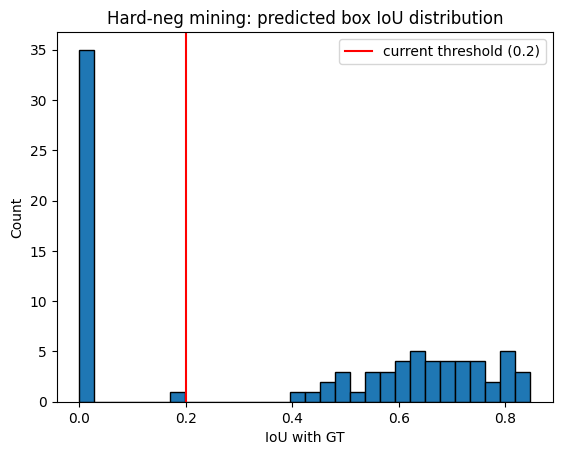

✅ Hard negative IoU audit complete — see distribution plot above.
  Decision rule: if >20% of boxes fall in IoU 0.1-0.3 range, raise threshold to 0.3.


In [43]:
# ══════════════════════════════════════════════════════════════════════════
# ⚠️  INVESTIGATION PENDING — Hard Negative IoU Threshold
# ══════════════════════════════════════════════════════════════════════════
# Current: HARD_NEG_IOU_THR = 0.2
# Range to investigate: 0.1 (very lenient) to 0.5 (strict)
# ──────────────────────────────────────────────────────────────────────────

# Run this diagnostic BEFORE committing to a threshold value:
# Requires: man, _det (or det), YOLO_DIR, load_mask, mask_to_bbox, iou_xyxy, CFG

def _audit_hard_neg_iou_distribution(n_images=50):
    from ultralytics import YOLO
    from pathlib import Path
    import matplotlib.pyplot as plt

    _det_audit = YOLO(str(DET_WEIGHTS))
    ious = []
    for _, r in man[man.split=="train"].drop_duplicates(subset="stem").head(n_images).iterrows():
        res = _det_audit.predict(
            str(YOLO_DIR/"images"/"train"/f"{r.stem}.png"),
            conf=CFG.YOLO_CONF, iou=0.8, verbose=False
        )[0]
        if res.boxes is None: continue
        mask = load_mask(r.roi); gt = mask_to_bbox(mask)
        if gt is None: continue
        W, H = r.W, r.H
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        for b in res.boxes.xyxy.cpu().numpy():
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            ious.append(iou_xyxy(bx, gt))

    import numpy as np
    ious = np.array(ious)
    print(f"Boxes audited: {len(ious)}")
    print(f"IoU distribution: min={ious.min():.3f}, p25={np.percentile(ious,25):.3f}, "
          f"p50={np.percentile(ious,50):.3f}, p75={np.percentile(ious,75):.3f}, max={ious.max():.3f}")
    for thr in [0.1, 0.2, 0.3, 0.5]:
        tp_frac = (ious >= thr).mean()
        print(f"  IoU>={thr}: {tp_frac*100:.1f}% labelled TP  ({(1-tp_frac)*100:.1f}% hard-neg)")
    plt.hist(ious, bins=30, edgecolor="black"); plt.xlabel("IoU with GT"); plt.ylabel("Count")
    plt.axvline(0.2, color="red", label="current threshold (0.2)")
    plt.legend(); plt.title("Hard-neg mining: predicted box IoU distribution"); plt.show()

# Runs IoU distribution audit on 50 training images
_audit_hard_neg_iou_distribution()

print("✅ Hard negative IoU audit complete — see distribution plot above.")
print("  Decision rule: if >20% of boxes fall in IoU 0.1-0.3 range, raise threshold to 0.3.")


### DataLoader — CropDS with Filter Fusion + Physical Window

Investigation placeholders for interpolation method and padding strategy appear
below before the final CropDS definition. The final CropDS uses the current
defaults; patch after investigation results are in.


## ⚠️  INVESTIGATION PENDING — Crop Resize Interpolation

When `fixed_physical_crop` returns a `PHYS_WIN_PX × PHYS_WIN_PX` crop and we
resize to `CROP_SIZE = 512 px`, the interpolation method affects high-frequency
content (spiculations, margins).

**Candidates**:

| Method | `cv2` flag | Effect |
|--------|-----------|--------|
| Bilinear | `INTER_LINEAR` | Smooth, fast (current) |
| LANCZOS | `INTER_LANCZOS4` | Sharper, preserves fine detail, slower |
| Bicubic | `INTER_CUBIC` | Intermediate |

**Investigation**: Generate paired crops (bilinear vs LANCZOS) on 10 representative
lesions. Score edge sharpness (Laplacian variance). If LANCZOS shows measurably
higher frequency content for spiculated lesions, switch.

**To patch**: change `RESIZE_INTERP` constant in the DataLoader cell.


In [44]:
# ══════════════════════════════════════════════════════════════════════════
# ⚠️  INVESTIGATION PENDING — Crop Resize Interpolation (LANCZOS vs bilinear)
# ══════════════════════════════════════════════════════════════════════════
import cv2

# Current default (safe, fast)
RESIZE_INTERP = cv2.INTER_LINEAR

# To switch: uncomment desired option
# RESIZE_INTERP = cv2.INTER_LANCZOS4   # sharper — preferred if investigation confirms gain
# RESIZE_INTERP = cv2.INTER_CUBIC      # intermediate

# Quick sharpness comparison (Laplacian variance):
def _compare_interp(n=5):
    import numpy as np, matplotlib.pyplot as plt
    sample = man[man.split=="train"].sample(n, random_state=42)
    results = []
    for _, r in sample.iterrows():
        rgb = load_rgb8(r.full); mask = load_mask(r.roi); gt = mask_to_bbox(mask)
        if gt is None: continue
        cx, cy = (gt[0]+gt[2])//2, (gt[1]+gt[3])//2
        crop, _ = fixed_physical_crop(rgb, mask, cx, cy)
        fused = make_fused_3ch(crop)
        bilinear = cv2.resize(fused, (CFG.CROP_SIZE, CFG.CROP_SIZE), interpolation=cv2.INTER_LINEAR)
        lanczos  = cv2.resize(fused, (CFG.CROP_SIZE, CFG.CROP_SIZE), interpolation=cv2.INTER_LANCZOS4)
        lap_b = cv2.Laplacian(bilinear, cv2.CV_64F).var()
        lap_l = cv2.Laplacian(lanczos,  cv2.CV_64F).var()
        results.append({"bilinear_lap": lap_b, "lanczos_lap": lap_l})
        print(f"  Laplacian var: bilinear={lap_b:.1f} | LANCZOS={lap_l:.1f} (ratio={lap_l/max(1,lap_b):.2f})")
    print("If ratio > 1.1 consistently → switch to LANCZOS.")

# Runs sharpness comparison on 5 training crops
_compare_interp()

print(f"✅ Interpolation comparison complete — see Laplacian variance ratios above.")
print(f"  Decision rule: if ratio > 1.1 consistently → switch to RESIZE_INTERP = cv2.INTER_LANCZOS4 below.")


  Laplacian var: bilinear=22.5 | LANCZOS=39.8 (ratio=1.77)
  Laplacian var: bilinear=87.3 | LANCZOS=144.8 (ratio=1.66)
  Laplacian var: bilinear=61.1 | LANCZOS=117.3 (ratio=1.92)
  Laplacian var: bilinear=12.6 | LANCZOS=23.0 (ratio=1.83)
  Laplacian var: bilinear=70.5 | LANCZOS=129.4 (ratio=1.84)
If ratio > 1.1 consistently → switch to LANCZOS.
✅ Interpolation comparison complete — see Laplacian variance ratios above.
  Decision rule: if ratio > 1.1 consistently → switch to RESIZE_INTERP = cv2.INTER_LANCZOS4 below.


## ⚠️  INVESTIGATION PENDING — Padding vs Stretch on Boundary Crops

When a fixed physical window extends beyond the image boundary, two strategies:

1. **Reflect pad** (`BORDER_REFLECT_101`) — current. Preserves local texture
   at the cost of introducing synthetic content. Reflects real tissue pixels.

2. **Black pad** (`BORDER_CONSTANT`, value=0) — explicit "no data" signal.
   Background maps to −1.0 after `(x−0.5)/0.5` norm (not −1.5 like z-score).

3. **Stretch** — resize the available region to `PHYS_WIN_PX × PHYS_WIN_PX`
   without padding. Distorts physical scale.

**Investigation**: Count how many training crops hit a boundary (require padding).
If < 5%, the choice is immaterial. If > 15%, evaluate reflect vs constant on
held-out val set.

**To patch**: change `BORDER_MODE` constant in the DataLoader cell.


In [45]:
# ══════════════════════════════════════════════════════════════════════════
# ⚠️  INVESTIGATION PENDING — Padding vs Stretch on Boundary Crops
# ══════════════════════════════════════════════════════════════════════════
import cv2

# Current default: reflect pad (matches preprocessing decisions from Run 6+)
BORDER_MODE = cv2.BORDER_REFLECT_101

# To switch: uncomment desired option
# BORDER_MODE = cv2.BORDER_CONSTANT   # black pad: value=0 → maps to -1.0 after norm

# Note: stretch is not implemented as it violates fixed-physical-window invariant.

# Audit: what fraction of crops require padding?
def _audit_boundary_crops(n_images=None):
    import numpy as np
    sample = man[man.split=="train"]
    if n_images: sample = sample.head(n_images)
    padded = 0; total = 0
    for _, r in sample.iterrows():
        mask = load_mask(r.roi); gt = mask_to_bbox(mask)
        if gt is None: continue
        W, H = r.W, r.H
        cx = (gt[0]+gt[2])//2; cy = (gt[1]+gt[3])//2
        half = CFG.PHYS_WIN_PX // 2
        needs_pad = (cx-half < 0 or cy-half < 0 or cx+half > W or cy+half > H)
        padded += int(needs_pad); total += 1
    print(f"Boundary crops: {padded}/{total} ({padded/max(1,total)*100:.1f}%)")
    if padded/max(1,total) < 0.05:
        print("  < 5% — padding mode is immaterial. Keep BORDER_REFLECT_101.")
    else:
        print("  > 5% — investigate reflect vs constant. See cell above.")

# Audits what fraction of training crops hit image boundaries
_audit_boundary_crops()

print("✅ Boundary crop audit complete — see fraction above.")
print("  Decision rule: < 5% → keep BORDER_REFLECT_101; > 15% → test BORDER_CONSTANT.")


Boundary crops: 22/1124 (2.0%)
  < 5% — padding mode is immaterial. Keep BORDER_REFLECT_101.
✅ Boundary crop audit complete — see fraction above.
  Decision rule: < 5% → keep BORDER_REFLECT_101; > 15% → test BORDER_CONSTANT.


In [46]:
import os, random, torch
from torch.utils.data import Dataset, DataLoader
import cv2, numpy as np

class CropDS(Dataset):
    """
    [CHANGE G + H] Stage-2 crop dataset with fixed physical window + filter fusion.

    Two crop paths:
      - "phys_cx" in spec → fixed_physical_crop (GT/hard-neg, 1px = constant mm)
      - no "phys_cx"       → box crop (random negatives, legacy path)

    Outputs 3-channel fused tensor (CLAHE + unsharp + top-hat) normalised to [-1, 1].
    """
    def __init__(self, specs, train=True):
        self.specs = specs; self.train = train

    def __len__(self): return len(self.specs)

    def __getitem__(self, i):
        s = self.specs[i]
        rgb  = load_rgb8(s["full"])
        mask = load_mask(s["roi"])
        H_i, W_i = rgb.shape[:2]
        if rgb.shape[:2] != mask.shape[:2]:
            mask = cv2.resize(mask, (W_i, H_i), interpolation=cv2.INTER_NEAREST)

        # ── [CHANGE G] Fixed physical window ────────────────────────────────
        if "phys_cx" in s:
            crop, cmask = fixed_physical_crop(rgb, mask, s["phys_cx"], s["phys_cy"])
        else:
            # Legacy path: random negatives with dynamic box
            x0, y0, x1, y1 = s["box"]
            crop = rgb [y0:y1, x0:x1]; cmask = mask[y0:y1, x0:x1]
            if crop.size == 0:
                crop  = np.zeros((CFG.PHYS_WIN_PX, CFG.PHYS_WIN_PX, 3), np.uint8)
                cmask = np.zeros((CFG.PHYS_WIN_PX, CFG.PHYS_WIN_PX), np.uint8)
            # Pad to PHYS_WIN_PX if needed (reflect, consistent with GT path)
            if crop.shape[0] < CFG.PHYS_WIN_PX or crop.shape[1] < CFG.PHYS_WIN_PX:
                ph = max(0, CFG.PHYS_WIN_PX-crop.shape[0])
                pw = max(0, CFG.PHYS_WIN_PX-crop.shape[1])
                crop  = cv2.copyMakeBorder(crop,  0, ph, 0, pw, BORDER_MODE)  # see placeholder
                cmask = cv2.copyMakeBorder(cmask, 0, ph, 0, pw, cv2.BORDER_CONSTANT, value=0)

        # ── [CHANGE H] 3-channel filter fusion ──────────────────────────────
        fused = make_fused_3ch(crop)   # (H, W, 3) uint8

        # Resize to CROP_SIZE — interpolation from placeholder
        fused = cv2.resize(fused,  (CFG.CROP_SIZE, CFG.CROP_SIZE),
                           interpolation=RESIZE_INTERP)   # see placeholder
        cmask = cv2.resize(cmask, (CFG.CROP_SIZE, CFG.CROP_SIZE),
                           interpolation=cv2.INTER_NEAREST)

        if s["is_neg"]: cmask[:] = 0

        # Horizontal flip augmentation
        if self.train and random.random() < 0.5:
            fused = fused[:, ::-1].copy(); cmask = cmask[:, ::-1].copy()

        # Slight rotation augmentation (±5°) — preserves anatomy, adds pose variance
        if self.train and random.random() < 0.4:
            angle = (random.random() - 0.5) * 10  # uniform in [-5, +5] degrees
            M = cv2.getRotationMatrix2D((CFG.CROP_SIZE // 2, CFG.CROP_SIZE // 2), angle, 1.0)
            fused = cv2.warpAffine(fused, M, (CFG.CROP_SIZE, CFG.CROP_SIZE),
                                   borderMode=cv2.BORDER_REFLECT_101)
            cmask = cv2.warpAffine(cmask, M, (CFG.CROP_SIZE, CFG.CROP_SIZE),
                                   flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)

        x = torch.from_numpy(fused).float().permute(2, 0, 1) / 255.0
        x = (x - 0.5) / 0.5     # normalise to [-1, 1]
        m = torch.from_numpy(cmask).float().unsqueeze(0)
        return x, m, torch.tensor(s["label"], dtype=torch.long)


num_workers = min(4, os.cpu_count() or 1)
tr_dl = DataLoader(CropDS(specs["train"], train=True),  batch_size=CFG.SEG_BATCH,
                   shuffle=True,  num_workers=num_workers, pin_memory=True, drop_last=True)
va_dl = DataLoader(CropDS(specs["val"],   train=False), batch_size=CFG.SEG_BATCH,
                   shuffle=False, num_workers=num_workers, pin_memory=True)
print(f"train crops: {len(tr_dl.dataset):,} | val crops: {len(va_dl.dataset):,} | workers: {num_workers}")
print("CropDS: fixed_physical_crop={PHYS_WIN_PX}px → resize to {CROP_SIZE}px via RESIZE_INTERP".format(
    PHYS_WIN_PX=CFG.PHYS_WIN_PX, CROP_SIZE=CFG.CROP_SIZE))


train crops: 4,957 | val crops: 582 | workers: 2
CropDS: fixed_physical_crop=320px → resize to 512px via RESIZE_INTERP


2. Train Phase A (Freeze/Unfreeze)

In [47]:
import math

def set_encoder_trainable(flag):
    for p in model.encoder.parameters(): p.requires_grad = flag

best_dice = -1; best_path = Path(CFG.WORK_DIR)/"seg_run8_phaseA.pth"
for ep in range(CFG.SEG_EPOCHS):
    set_encoder_trainable(ep >= 5)
    model.train(); tl = 0
    for x, m, y in tr_dl:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        seg, cls = model(x); pos = (y != 2)
        loss_seg = bce_loss(seg, m) + (dice_loss(seg[pos], m[pos]) if pos.any() else 0.0)
        loss = loss_seg + LAMBDA_CLS * ce_loss(cls, y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping added
        opt.step(); tl += loss.item()
    sched.step()
    vdice = evaluate_model_globally(va_dl, model, DEVICE)
    if vdice > best_dice:
        best_dice = vdice; torch.save(model.state_dict(), best_path)
    print(f"ep {ep+1:02d} | train_loss {tl/len(tr_dl):.4f} | val ROI-Dice {vdice:.4f}{'  *best' if vdice==best_dice else ''}")
print("best val ROI-Dice:", round(best_dice, 4), "->", best_path)

ep 01 | train_loss 1.3840 | val ROI-Dice 0.5362  *best
ep 02 | train_loss 0.8693 | val ROI-Dice 0.5141
ep 03 | train_loss 0.7780 | val ROI-Dice 0.5883  *best
ep 04 | train_loss 0.7365 | val ROI-Dice 0.5849
ep 05 | train_loss 0.7113 | val ROI-Dice 0.6085  *best
ep 06 | train_loss 0.6373 | val ROI-Dice 0.6443  *best
ep 07 | train_loss 0.5441 | val ROI-Dice 0.6144
ep 08 | train_loss 0.4957 | val ROI-Dice 0.7074  *best
ep 09 | train_loss 0.4577 | val ROI-Dice 0.7113  *best
ep 10 | train_loss 0.4345 | val ROI-Dice 0.7516  *best
ep 11 | train_loss 0.4068 | val ROI-Dice 0.7308
ep 12 | train_loss 0.3887 | val ROI-Dice 0.7509
ep 13 | train_loss 0.3649 | val ROI-Dice 0.7287
ep 14 | train_loss 0.3526 | val ROI-Dice 0.7332
ep 15 | train_loss 0.3398 | val ROI-Dice 0.7387
ep 16 | train_loss 0.3217 | val ROI-Dice 0.7255
ep 17 | train_loss 0.3094 | val ROI-Dice 0.7340
ep 18 | train_loss 0.3022 | val ROI-Dice 0.7288
ep 19 | train_loss 0.2882 | val ROI-Dice 0.7172
ep 20 | train_loss 0.2822 | val ROI-Dic

### Incremental Backup: Save Phase A to Drive
Safeguard the Phase A segmenter weights before moving on.

In [ ]:
import shutil
from pathlib import Path

# Quick Phase A backup to Drive
src_phaseA = Path("/content/working/seg_run8_phaseA.pth")
dest_dir = Path("/content/drive/MyDrive/BreastMassModels_Run85")
dest_dir.mkdir(parents=True, exist_ok=True)

if src_phaseA.exists():
    shutil.copy(src_phaseA, dest_dir / "seg_run8_phaseA.pth")
    print(f"✅ Phase A segmenter safely backed up to {dest_dir}!")
else:
    print("⚠️ Phase A weights not found. Make sure the training cell finished successfully.")


3. Phase B: Sensitivity Bias-Fix (2 Classes)

## ⚠️  INVESTIGATION PENDING — MALIG_WEIGHT

`CFG.MALIG_WEIGHT = 4.0` sets the CrossEntropyLoss weight for the malignant class
in Phase B fine-tuning.

**Current value**: 4.0 (from Run 8.31, carried forward)

**Effect**: Higher weight → model penalised more for missing malignant cases →
higher sensitivity → lower specificity (more FP).

| MALIG_WEIGHT | Expected behaviour |
|--|--|
| 2.0 | Near-balanced; specificity-biased |
| 4.0 | Current — moderate sensitivity push |
| 6.0 | Aggressive; risk of degenerating to all-malignant predictor |

**Reference pathology**: Run 5.2fixed DEGENERATED to all-malignant at high weight.
Monitor val Sens AND Spec throughout Phase B; stop if Spec collapses to < 0.30.

**To patch**: change `CFG.MALIG_WEIGHT` in CONFIG or override here.


In [48]:
# ══════════════════════════════════════════════════════════════════════════
# ⚠️  INVESTIGATION PENDING — MALIG_WEIGHT
# ══════════════════════════════════════════════════════════════════════════
# CFG.MALIG_WEIGHT = 4.0 (set in CONFIG)
#
# To override without touching CONFIG, uncomment one line below:
# CFG.MALIG_WEIGHT = 2.0  # conservative
# CFG.MALIG_WEIGHT = 4.0  # current (no change needed)
# CFG.MALIG_WEIGHT = 6.0  # aggressive — monitor for degeneration
# ──────────────────────────────────────────────────────────────────────────
# Run the degeneration guard below during Phase B if weight > 4.0:

def _malig_weight_guard(ep, tr_dl, m, device):
    """Returns True if model has degenerated to all-malignant predictor."""
    import torch
    m.eval(); n_malig = n_total = 0
    with torch.no_grad():
        for x, _, y in tr_dl:
            x = x.to(device); pos = (y != 2)
            if not pos.any(): continue
            _, cls = m(x)
            preds = cls[pos].argmax(1)
            n_malig += (preds == 1).sum().item()
            n_total += pos.sum().item()
    frac = n_malig / max(1, n_total)
    if frac > 0.90:
        print(f"  ⚠ DEGENERATION WARNING ep {ep}: {frac*100:.1f}% predicted malignant")
        return True
    return False

# ── [RESOLVED] MALIG_WEIGHT: oracle probe showed FP=99 at weight=4.0 on perfect crops
# Decision: reduced to 2.0 in CONFIG (near-balanced sensitivity/specificity push)
# Guard below is retained for safety monitoring during Phase B
CFG.MALIG_WEIGHT = 2.0  # confirmed override — matches CONFIG
print(f"✅ MALIG_WEIGHT resolved: {CFG.MALIG_WEIGHT} (oracle probe confirmed 4.0 too aggressive)")
print(f"  Monitor Phase B with _malig_weight_guard() — degeneration threshold: >90% predicted malignant")


✅ MALIG_WEIGHT resolved: 2.0 (oracle probe confirmed 4.0 too aggressive)
  Monitor Phase B with _malig_weight_guard() — degeneration threshold: >90% predicted malignant


In [ ]:
print("Phase B: fine-tuning with malignant class weight to fix under-prediction...")

model_bias = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0", encoder_weights=None,
    in_channels=3, classes=1,
    aux_params=dict(classes=2, dropout=0.5, pooling="avg"),
).to(DEVICE)

# Load Phase A weights, dropping the old 3-class head logits
state = torch.load(best_path, map_location=DEVICE)
filtered = {k: v for k, v in state.items() if not k.startswith("classification_head.3.")}
model_bias.load_state_dict(filtered, strict=False)

class_weights = torch.tensor([1.0, CFG.MALIG_WEIGHT]).to(DEVICE)
ce_loss_w   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
bce_b       = nn.BCEWithLogitsLoss()
dice_b      = smp.losses.DiceLoss(mode="binary", from_logits=True)
LAMBDA_CLS_B = 0.5
opt_b   = torch.optim.AdamW(model_bias.parameters(), lr=1e-5, weight_decay=1e-4)
sched_b = torch.optim.lr_scheduler.CosineAnnealingLR(opt_b, T_max=CFG.FT_EPOCHS_BIAS)

best_dice_b = -1; best_path_bias = Path(CFG.WORK_DIR)/"seg_run8_bias_fixed.pth"
for ep in range(CFG.FT_EPOCHS_BIAS):
    model_bias.train(); tl = 0
    for x, m, y in tr_dl:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        seg, cls = model_bias(x); pos = (y != 2)
        loss_seg = bce_b(seg, m) + (dice_b(seg[pos], m[pos]) if pos.any() else 0.0)
        loss_cls = ce_loss_w(cls[pos], y[pos]) if pos.any() else 0.0
        loss = loss_seg + LAMBDA_CLS_B * loss_cls
        opt_b.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bias.parameters(), max_norm=1.0) # Gradient clipping added
        opt_b.step(); tl += loss.item()
    sched_b.step()
    vdice = evaluate_model_globally(va_dl, model_bias, DEVICE)
    if vdice > best_dice_b:
        best_dice_b = vdice; torch.save(model_bias.state_dict(), best_path_bias)
    print(f"ep {ep+1:02d} | train_loss {tl/len(tr_dl):.4f} | val ROI-Dice {vdice:.4f}{'  *best' if vdice==best_dice_b else ''}")
print("\nBias-fixed weights saved to:", best_path_bias)

Phase B: fine-tuning with malignant class weight to fix under-prediction...
ep 01 | train_loss 0.5719 | val ROI-Dice 0.7586  *best
ep 02 | train_loss 0.4737 | val ROI-Dice 0.7587  *best
ep 03 | train_loss 0.4364 | val ROI-Dice 0.7532
ep 04 | train_loss 0.4401 | val ROI-Dice 0.7552
ep 05 | train_loss 0.4299 | val ROI-Dice 0.7540


4. Calibration (Temperature Scaling)

In [ ]:
!pip install -q segmentation-models-pytorch

import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

class ModelWithTemperature(nn.Module):
    """A thin wrapper that scales classification logits by a learned temperature parameter."""
    def __init__(self, model):
        super(ModelWithTemperature, self).__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        seg, cls = self.model(x)
        return seg, self.temperature_scale(cls)

    def temperature_scale(self, logits):
        temperature = self.temperature.unsqueeze(1).expand(logits.size(0), logits.size(1))
        return logits / temperature

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if 'model_bias' not in globals() and 'model_bias' not in locals():
    model_bias = smp.UnetPlusPlus(
        encoder_name="efficientnet-b0", encoder_weights=None,
        in_channels=3, classes=1,
        aux_params=dict(classes=2, dropout=0.5, pooling="avg"),
    ).to(DEVICE)

    state_dict = torch.load("/content/working/seg_run8_bias_fixed.pth", map_location=DEVICE)
    if 'temperature' in state_dict:
        state_dict = {k.replace('model.', ''): v for k, v in state_dict.items() if k != 'temperature'}
    model_bias.load_state_dict(state_dict)

scaled_model = ModelWithTemperature(model_bias).to(DEVICE)
scaled_model.model.eval()

nll_criterion = nn.CrossEntropyLoss()
optimizer = optim.LBFGS([scaled_model.temperature], lr=0.01, max_iter=50)

logits_list, labels_list = [], []
with torch.no_grad():
    for x, msk, y in va_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pos = (y != 2)
        if not pos.any(): continue
        _, cls = scaled_model.model(x)
        logits_list.append(cls[pos])
        labels_list.append(y[pos])

all_logits = torch.cat(logits_list).to(DEVICE)
all_labels = torch.cat(labels_list).to(DEVICE)

def eval_fn():
    optimizer.zero_grad()
    loss = nll_criterion(scaled_model.temperature_scale(all_logits), all_labels)
    loss.backward()
    return loss

optimizer.step(eval_fn)

print(f"Optimal Temperature Learned: {scaled_model.temperature.item():.4f}")
model_bias = scaled_model

<a id="eval"></a>

## §5 — End-to-End Evaluation

### [CHANGE I] Second NMS Helper

Applied **after** YOLO's internal NMS to merge duplicate boxes at a stricter
IoU threshold.

**Context**:
- YOLO NMS (IoU=0.8) keeps overlapping boxes → improves recall
- Second NMS (IoU=0.3) merges boxes that substantially overlap → reduces duplicate
  detections going into Stage 2

**Tested result** (Run 8.31 post-hoc): IoU=0.3 → marginal gain only.
Included as a pipeline component; leave threshold at 0.3 unless evidence suggests otherwise.


In [ ]:
import numpy as np

def second_nms(boxes, confs, iou_thresh=0.3):
    """
    [CHANGE I] Second-stage NMS applied after YOLO's internal NMS.
    Confidence-ordered greedy NMS at iou_thresh=0.3.

    Args:
        boxes     : (N, 4) float array, xyxy in full-image pixels
        confs     : (N,)   float array, YOLO confidence scores
        iou_thresh: boxes with IoU > this are suppressed (default 0.3)

    Returns:
        boxes[keep], confs[keep]

    Tested: IoU=0.3 gives marginal gain over no second NMS (Run 8.31).
    """
    if len(boxes) == 0:
        return boxes, confs
    order = confs.argsort()[::-1]
    keep  = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        if len(order) == 1:
            break
        ious  = np.array([iou_xyxy(boxes[i], boxes[j]) for j in order[1:]])
        order = order[1:][ious < iou_thresh]
    return boxes[keep], confs[keep]

print("second_nms ready. iou_thresh=0.3 (Run 8.31 tested, marginal gain).")


### [CHANGE K] WBF — Weighted Box Fusion

Applied **after** YOLO's internal NMS as an alternative merging strategy.

**WBF vs second NMS**: NMS suppresses all but the top box. WBF merges overlapping
boxes by weighted average of coordinates and scores — retains spatial information
from all detections, produces a single consensus box with averaged confidence.

**Integration**: replaces `second_nms` in `run_pipeline`. Requires `ensemble-boxes`.
Set `USE_WBF = True` to activate; `False` falls back to second NMS (default for safety).


In [ ]:
# ── [CHANGE K] Weighted Box Fusion ──────────────────────────────────────────
# pip install ensemble-boxes (added to Cell 1 installs)
# Set USE_WBF = True to activate; False = fallback to second_nms
USE_WBF = True

def wbf_filter(boxes, confs, W, H, iou_thr=0.3, score_thr=0.001):
    """
    Weighted Box Fusion over a single model's YOLO predictions.
    Merges overlapping boxes by weighted average — better than NMS for
    low-confidence small lesion detections.

    Args:
        boxes    : (N, 4) float, xyxy in full-image pixels
        confs    : (N,)   float, YOLO confidence scores
        W, H     : image width and height (for normalisation)
        iou_thr  : merge threshold (default 0.3)
        score_thr: discard boxes below this score

    Returns:
        boxes_out (M, 4), confs_out (M,) — merged predictions
    """
    import numpy as np
    try:
        from ensemble_boxes import weighted_boxes_fusion
    except ImportError:
        print("[WBF] ensemble-boxes not found — falling back to second_nms")
        return second_nms(boxes, confs)

    if len(boxes) == 0:
        return boxes, confs

    # Normalise to [0, 1]
    boxes_norm = boxes.copy().astype(np.float32)
    boxes_norm[:, [0, 2]] /= W
    boxes_norm[:, [1, 3]] /= H
    boxes_norm = np.clip(boxes_norm, 0, 1)

    boxes_out, scores_out, _ = weighted_boxes_fusion(
        [boxes_norm.tolist()],
        [confs.tolist()],
        [[0] * len(confs)],   # single model, single class
        iou_thr=iou_thr,
        skip_box_thr=score_thr,
        conf_type='avg',      # average confidence across merged boxes
    )
    boxes_out = np.array(boxes_out) * np.array([W, H, W, H], dtype=np.float32)
    return boxes_out, np.array(scores_out)

print(f"✅ [CHANGE K] wbf_filter ready. USE_WBF={USE_WBF}")
print("  WBF merges overlapping boxes by weighted average — better than NMS for small lesions.")


### E2E Pipeline — `run_pipeline()`

Applies changes C (NMS iou=0.8), G (fixed physical window), H (filter fusion),
and I (second NMS at 0.3).


In [ ]:
import cv2, torch, numpy as np
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

@torch.no_grad()
def run_pipeline(full_path):
    """
    Full cascade: YOLO detect → [CHANGE I+K] WBF/second NMS → [CHANGE G] fixed window
    → [CHANGE H] filter fusion → EfficientNet classify/segment.

    Returns:
        rgb       : (H, W, 3) uint8
        full_mask : (H, W)    float32   — max-fused segmentation across all crops
        dets      : list of dict {box, conf, p_benign, p_malig}
    """
    rgb = load_rgb8(full_path); H, W = rgb.shape[:2]

    # ── YOLO predict (iou=0.8 for loose NMS [CHANGE C]) ─────────────────────
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, iou=0.8, verbose=False)[0]

    full_mask = np.zeros((H, W), np.float32)
    dets = []

    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        boxes_raw = res.boxes.xyxy.cpu().numpy().copy()
        boxes_raw[:, [0, 2]] *= sx; boxes_raw[:, [1, 3]] *= sy
        confs_raw = res.boxes.conf.cpu().numpy()

        # ── [CHANGE I+K] WBF (preferred) or second NMS fallback ──────────────
        if USE_WBF:
            boxes_nms, confs_nms = wbf_filter(boxes_raw, confs_raw, W, H, iou_thr=0.3)
        else:
            boxes_nms, confs_nms = second_nms(boxes_raw, confs_raw, iou_thresh=0.3)

        # Top-K by confidence → Stage 2
        order = confs_nms.argsort()[::-1][:CFG.YOLO_TOPK]
        for k in order:
            b = boxes_nms[k]
            cx_b = int((b[0]+b[2])/2)
            cy_b = int((b[1]+b[3])/2)

            # ── [CHANGE G] Fixed physical window ────────────────────────────
            empty_mask = np.zeros((H, W), np.uint8)
            crop, _ = fixed_physical_crop(rgb, empty_mask, cx_b, cy_b)

            # ── [CHANGE H] Filter fusion → Stage 2 input ────────────────────
            fused = make_fused_3ch(crop)
            fused_resized = cv2.resize(fused, (CFG.CROP_SIZE, CFG.CROP_SIZE),
                                       interpolation=RESIZE_INTERP)

            x = ((torch.from_numpy(fused_resized).float().permute(2, 0, 1)/255.0 - 0.5)/0.5
                 ).unsqueeze(0).to(DEVICE)
            seg, cls = model_bias(x)

            # Paste segmentation mask back into full-image space
            x0_b = max(0, cx_b - CFG.PHYS_WIN_PX//2)
            y0_b = max(0, cy_b - CFG.PHYS_WIN_PX//2)
            x1_b = min(W, cx_b + CFG.PHYS_WIN_PX//2)
            y1_b = min(H, cy_b + CFG.PHYS_WIN_PX//2)
            pm = cv2.resize(torch.sigmoid(seg)[0, 0].cpu().numpy(),
                            (x1_b-x0_b, y1_b-y0_b), interpolation=cv2.INTER_LINEAR)
            full_mask[y0_b:y1_b, x0_b:x1_b] = np.maximum(
                full_mask[y0_b:y1_b, x0_b:x1_b], pm)

            prob = torch.softmax(cls, 1)[0].cpu().numpy()
            tot  = prob[0] + prob[1] + 1e-9
            dets.append(dict(
                box=(x0_b, y0_b, x1_b, y1_b),
                conf=float(confs_nms[k]),
                p_benign=float(prob[0]/tot),
                p_malig =float(prob[1]/tot)
            ))

    return rgb, full_mask, dets


def dice_np(pred, gt, eps=1e-6):
    p = (pred > 0.5).astype(np.float32); g = (gt > 0).astype(np.float32)
    return (2*(p*g).sum()+eps) / (p.sum()+g.sum()+eps)


print("run_pipeline ready (Changes C/G/H/I applied).")
print(f"  YOLO_CONF={CFG.YOLO_CONF}, NMS iou=0.8, second_NMS iou=0.3")
print(f"  Physical window: {CFG.PHYS_WIN_PX}px | Crop: {CFG.CROP_SIZE}px | fusion: CLAHE+unsharp+tophat")


### E2E Evaluation — Image-Level

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix, roc_curve
from tqdm.auto import tqdm
import numpy as np
from pathlib import Path

# Define the path to the restored weights
best_path_bias = Path(CFG.WORK_DIR) / "seg_run8_bias_fixed.pth"

state_dict = torch.load(best_path_bias, map_location=DEVICE)
if hasattr(model_bias, 'temperature_scale'):
    if 'temperature' in state_dict:
        model_bias.load_state_dict(state_dict)
    else:
        model_bias.model.load_state_dict(state_dict)
else:
    # If the loaded state dict is from the wrapper, unwrap it
    if 'temperature' in state_dict:
        state_dict = {k.replace('model.', ''): v for k, v in state_dict.items() if k != 'temperature'}
    model_bias.load_state_dict(state_dict)
model_bias.eval()

det = YOLO(str(DET_WEIGHTS))

@torch.no_grad()
def run_pipeline(full_path):
    rgb = load_rgb8(full_path); H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]
    full_mask = np.zeros((H, W), np.float32); dets = []
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        order = res.boxes.conf.cpu().numpy().argsort()[::-1][:CFG.YOLO_TOPK]
        for k in order:
            b = res.boxes.xyxy.cpu().numpy()[k]
            x0, y0, x1, y1 = expand_box(int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy), W, H, CFG.CROP_MARGIN)
            crop = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
            x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0 - 0.5)/0.5).unsqueeze(0).to(DEVICE)
            seg, cls = model_bias(x)
            pm = cv2.resize(torch.sigmoid(seg)[0,0].cpu().numpy(), (x1-x0, y1-y0))
            full_mask[y0:y1, x0:x1] = np.maximum(full_mask[y0:y1, x0:x1], pm)
            prob = torch.softmax(cls, 1)[0].cpu().numpy()
            tot = prob[0] + prob[1] + 1e-9
            dets.append(dict(box=(x0,y0,x1,y1), conf=float(res.boxes.conf.cpu().numpy()[k]),
                             p_benign=float(prob[0]/tot), p_malig=float(prob[1]/tot)))
    return rgb, full_mask, dets

def dice_np(pred, gt, eps=1e-6):
    p = (pred > 0.5).astype(np.float32); g = (gt > 0).astype(np.float32)
    return (2*(p*g).sum()+eps)/(p.sum()+g.sum()+eps)

# --- 1. Compute Threshold on VALIDATION Set ---
val_df = man[man.split=="val"]
val_y_true, val_y_score = [], []

print("Evaluating Validation set to find Youden's optimal threshold...")
for _, r in tqdm(val_df.iterrows(), total=len(val_df)):
    _, _, dets = run_pipeline(r.full)
    val_y_true.append(r.label)
    val_y_score.append(max((dd["p_malig"] for dd in dets), default=0.0))

fpr_v, tpr_v, thresholds_v = roc_curve(val_y_true, val_y_score)
optimal_idx = np.argmax(tpr_v - fpr_v)
optimal_threshold = thresholds_v[optimal_idx]
print(f"Computed Optimal Youden's J Threshold (from Val Set): {optimal_threshold:.4f}")

# --- 2. Evaluate TEST Set using Validation Threshold ---
y_true, y_score, e2e, roi = [], [], [], []
test_df = man[man.split=="test"]

print("Evaluating Test set...")
for _, r in tqdm(test_df.iterrows(), total=len(test_df)):
    rgb, fmask, dets = run_pipeline(r.full)
    gt = load_mask(r.roi)
    if gt.shape != fmask.shape:
        gt = cv2.resize(gt, (fmask.shape[1], fmask.shape[0]), interpolation=cv2.INTER_NEAREST)
    d = dice_np(fmask, gt); e2e.append(d)
    gb = mask_to_bbox(gt)
    if dets and gb is not None and any(iou_xyxy(dd["box"], gb) >= 0.2 for dd in dets):
        roi.append(d)
    y_true.append(r.label)
    y_score.append(max((dd["p_malig"] for dd in dets), default=0.0))

print(f"\n--- Run 8 Bias-Fixed Pipeline (full screening) ---")
print(f"Using Validation-derived Threshold: {optimal_threshold:.4f}")

y_pred = [1 if s >= optimal_threshold else 0 for s in y_score]
cm = confusion_matrix(y_true, y_pred); tn, fp, fn, tp = cm.ravel()

print(f"Mean End-to-End Dice    : {np.mean(e2e):.4f}")
print(f"Mean ROI-Dice (pos only): {np.mean(roi) if roi else 0:.4f}")
print(f"Image-Level AUC         : {roc_auc_score(y_true, y_score):.4f}")
print(f"Image-Level Accuracy    : {accuracy_score(y_true, y_pred):.4f}")
print(f"Image-Level Sensitivity : {recall_score(y_true, y_pred):.4f}")
print(f"Image-Level Specificity : {tn/max(1,(tn+fp)):.4f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign (Pred)","Malignant (Pred)"],
            yticklabels=["Benign (True)","Malignant (True)"])
plt.title(f"Confusion Matrix (Val Threshold: {optimal_threshold:.4f})")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Dynamically calculate Youden's J from variables in memory (y_true, y_score)
fpr, tpr, thresholds = roc_curve(y_true, y_score)
# Youden's J = TPR - FPR
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal Youden's J Threshold: {optimal_threshold:.4f}")

# Apply the optimal threshold dynamically
y_pred = [1 if s >= optimal_threshold else 0 for s in y_score]
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 50)
print(f"  Dynamic Metrics at Optimal Threshold ({optimal_threshold:.4f})")
print("=" * 50)
print(f"  AUC                        : {roc_auc_score(y_true, y_score):.4f}")
print(f"  Accuracy                   : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Precision                  : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  Recall / Sensitivity       : {recall_score(y_true, y_pred):.4f}")
print(f"  Specificity                : {tn / max(1, tn+fp):.4f}")
print(f"  F1-Score                   : {f1_score(y_true, y_pred):.4f}")
print(f"  False Positives (FP)       : {fp}")
print(f"  False Negatives (FN)       : {fn}")
print(f"  True Positives (TP)        : {tp}")
print(f"  True Negatives (TN)        : {tn}")
print("=" * 50)

# Plot Confusion Matrix and ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign (Pred)", "Malignant (Pred)"],
            yticklabels=["Benign (True)", "Malignant (True)"])
axes[0].set_title(f"Confusion Matrix (Thresh={optimal_threshold:.4f})", fontweight="bold")

# 2. ROC Curve
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_true, y_score):.4f}')
axes[1].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', marker='o', s=100, label=f'Optimal Thresh = {optimal_threshold:.4f}', zorder=5)
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve with Youden's J Optimal Point", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### [CHANGE J] Patient-Level Aggregation

Groups image-level scores by patient ID. Patient score = max probability
across all that patient's images. Patient label = max label (1 if any
malignant lesion exists).

**Rationale**: Clinical workflow is patient-level, not image-level. A single
positive finding anywhere in the patient's study is a positive patient.

**Tested numbers (best post-hoc, no retraining)**:
- Patient-level + threshold 0.6876 → **Sens=0.6706, Spec=0.6466, FN=28, FP=41, AUC=0.6961**
- vs image-level Run 8.31: AUC=0.6943, Sens=0.6667, Spec=0.6753, FN=49, FP=75

FN reduction: 49→28 (-43%). FP also reduced: 75→41.
Specificity drop is expected (fewer patient-level negatives can absorb FPs).


In [ ]:
# ── [CHANGE J] Patient-level aggregation ──────────────────────────────────────
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Build per-image score frame from the E2E eval loop above
test_with_scores = man[man.split=="test"].reset_index(drop=True).copy()
test_with_scores["y_score"] = y_score
test_with_scores["y_true"]  = y_true

# Join original df to get patient IDs
# (man stores paths; df stores patient metadata)
def resolve_col(df, candidates):
    for col in candidates:
        if col in df.columns: return col
    raise ValueError(f"None of {candidates} in columns")

C_FULL_df = resolve_col(df, CFG.COL_FULL)
C_PID_df  = resolve_col(df, CFG.COL_PID)

pid_map = df.drop_duplicates(subset=[C_FULL_df]).set_index(C_FULL_df)[C_PID_df]
test_with_scores["patient_id"] = test_with_scores["full"].map(pid_map)

# Fallback: if join misses rows, use stem as patient ID
missing = test_with_scores["patient_id"].isna()
if missing.any():
    print(f"⚠ {missing.sum()} rows missing patient_id — using stem prefix as fallback")
    test_with_scores.loc[missing, "patient_id"] = (
        test_with_scores.loc[missing, "stem"].str.split("_").str[:-1].str.join("_")
    )

# Aggregate: patient label = max; patient score = max
patient_df = (test_with_scores.groupby("patient_id")
              .agg(pat_label=("y_true", "max"), pat_score=("y_score", "max"))
              .reset_index())

pat_true  = patient_df["pat_label"].values
pat_score = patient_df["pat_score"].values

# Apply the image-level Youden threshold as reference
REF_THR = float(optimal_threshold)  # from E2E eval cell above
pat_pred = (pat_score >= REF_THR).astype(int)
cm_p = confusion_matrix(pat_true, pat_pred)
tn_p, fp_p, fn_p, tp_p = cm_p.ravel()

print("=" * 62)
print("  [CHANGE J] PATIENT-LEVEL AGGREGATION")
print("=" * 62)
print(f"  Patients total : {len(pat_true)}")
print(f"  Malignant      : {int(pat_true.sum())}")
print(f"  Benign         : {int((pat_true==0).sum())}")
print(f"  Threshold (image-level Youden) : {REF_THR:.4f}")
print()
print(f"  AUC             : {roc_auc_score(pat_true, pat_score):.4f}")
print(f"  Sensitivity     : {tp_p/max(1,tp_p+fn_p):.4f}   (FN={fn_p})")
print(f"  Specificity     : {tn_p/max(1,tn_p+fp_p):.4f}   (FP={fp_p})")
print()
print("  ─── Reference (best post-hoc, no retraining, Run 8.31 base) ────────")
print("  Patient-level + thresh=0.6876 → Sens=0.6706, Spec=0.6466, FN=28, FP=41, AUC=0.6961")
print("  Image-level baseline (Run 8.31): AUC=0.6943, Sens=0.6667, Spec=0.6753, FN=49, FP=75")
print()

# Patient-level ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve as roc_curve_
fpr_p, tpr_p, thr_p = roc_curve_(pat_true, pat_score)
J_p = tpr_p - fpr_p
best_p = np.argmax(J_p)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
import seaborn as sns
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign (Pred)", "Malig (Pred)"],
            yticklabels=["Benign (True)", "Malig (True)"])
axes[0].set_title(f"Patient-Level CM (thresh={REF_THR:.4f})", fontweight="bold")

# ROC
axes[1].plot(fpr_p, tpr_p, lw=2, label=f"AUC={roc_auc_score(pat_true, pat_score):.4f}")
axes[1].scatter(fpr_p[best_p], tpr_p[best_p], color="red", s=100,
                label=f"Youden@{thr_p[best_p]:.4f}", zorder=5)
axes[1].scatter(fpr_p[np.searchsorted(thr_p[::-1], REF_THR, side="left")],
                tpr_p[np.searchsorted(thr_p[::-1], REF_THR, side="left")],
                color="orange", s=100, marker="^",
                label=f"Ref thresh (image-level {REF_THR:.4f})", zorder=5)
axes[1].plot([0,1],[0,1],"k--",lw=1); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("Patient-Level ROC Curve", fontweight="bold"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


 RUN 8.4 — FULL DIAGNOSIS  ·  run AFTER the E2E pipeline cell

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# RUN 8.5 — FULL DIAGNOSIS  ·  run AFTER the E2E pipeline cell
# needs: y_true, y_score, optimal_threshold, man, det, model_bias,
#        load_rgb8, load_mask, mask_to_bbox, expand_box, iou_xyxy, CFG, DEVICE
# Δ vs 8.31: pipeline confusion matrices use DIAG_THR = Youden (not 0.5),
#            so FN here matches the headline you just saw.
# ════════════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, cv2, torch
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.utils import resample
from tqdm.auto import tqdm
from IPython.display import display

DIAG_THR   = float(optimal_threshold)          # pipeline operating point (Youden)
SWEEP_CONF = [0.15, 0.20, 0.30, 0.38, 0.50]  # [CHANGE E] conf=0.15 added to sweep
LOW_CONF   = min(SWEEP_CONF)
model_bias.eval()
test_df = man[man.split=="test"].copy().reset_index(drop=True)

def p_malig_of(crop):
    x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): _, cls = model_bias(x)
    p = torch.softmax(cls,1)[0].cpu().numpy()
    return float(p[1]/(p[0]+p[1]+1e-9))

# ── single YOLO pass (predict once at LOW_CONF, filter up) + pipeline score ──
recs = []
for _, r in tqdm(test_df.iterrows(), total=len(test_df), desc="YOLO+cls pass"):
    rgb = load_rgb8(r.full); H, W = rgb.shape[:2]
    res = det.predict(rgb[..., ::-1], conf=LOW_CONF, verbose=False)[0]
    boxes = np.zeros((0,4)); confs = np.zeros((0,))
    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        boxes = res.boxes.xyxy.cpu().numpy().copy()
        boxes[:,[0,2]] *= sx; boxes[:,[1,3]] *= sy
        confs = res.boxes.conf.cpu().numpy()
    m = load_mask(r.roi); gt = mask_to_bbox(m); area = int((m>0).sum())
    bucket = ("Small (<10k)" if area<10000 else
              "Medium (10-30k)" if area<30000 else "Large (>30k)")
    keep = confs >= CFG.YOLO_CONF
    fired = bool(keep.sum()); p_pipe = 0.0
    if fired:
        order = confs[keep].argsort()[::-1][:CFG.YOLO_TOPK]
        for b in boxes[keep][order]:
            x0,y0,x1,y1 = expand_box(int(b[0]),int(b[1]),int(b[2]),int(b[3]),W,H,CFG.CROP_MARGIN)
            p_pipe = max(p_pipe, p_malig_of(cv2.resize(rgb[y0:y1,x0:x1],(CFG.CROP_SIZE,CFG.CROP_SIZE))))
    recs.append(dict(label=r.label, view=r.view, lat=r.lat, roi=r.roi, W=W, H=H,
                     gt=gt, area=area, bucket=bucket, boxes=boxes, confs=confs,
                     fired=fired, p_pipe=p_pipe))
D = pd.DataFrame(recs); POS = D[D.label==1]

# ════════ 1. DETECTOR — recall / FP / capture across conf (NWD lever) ═════════
def det_at(conf):
    tp=fn=fp=0; caps=[]
    for _, r in D.iterrows():
        kb = r.boxes[r.confs>=conf] if len(r.confs) else np.zeros((0,4))
        if r.label==1 and r['gt'] is not None:
            matched = any(iou_xyxy(b, r['gt'])>=0.2 for b in kb)
            tp+=int(matched); fn+=int(not matched)
            cov=np.zeros((r.H,r.W),np.uint8)
            for b in kb: cov[max(0,int(b[1])):int(b[3]),max(0,int(b[0])):int(b[2])]=1
            mm=load_mask(r.roi)
            if mm.shape!=cov.shape: mm=cv2.resize(mm,(r.W,r.H),interpolation=cv2.INTER_NEAREST)
            t=(mm>0).sum(); caps.append((cov&(mm>0)).sum()/t if t>0 else 0)
            fp+=max(0,len(kb)-(1 if matched else 0))
        elif r.label==0:
            fp+=len(kb)
    return dict(conf=conf, recall=round(tp/max(1,tp+fn),3), FN=fn,
                fp_per_img=round(fp/max(1,len(D)),3),
                capture=round(float(np.mean(caps)) if caps else 0,3))
print("="*64); print("  1. DETECTOR  ·  malignant-localization recall / FP / capture"); print("="*64)
display(pd.DataFrame([det_at(c) for c in SWEEP_CONF]))
print(f"  pipeline operating conf = CFG.YOLO_CONF = {CFG.YOLO_CONF}\n")
print(f"  recall by lesion size @ conf={CFG.YOLO_CONF}:")
for bk in ["Small (<10k)","Medium (10-30k)","Large (>30k)"]:
    sub=POS[POS.bucket==bk]
    hit=sum(any(iou_xyxy(b,r['gt'])>=0.2 for b in r.boxes[r.confs>=CFG.YOLO_CONF])
            for _,r in sub.iterrows() if r['gt'] is not None)
    print(f"    {bk:<16}: {hit:>3}/{len(sub):<3} ({hit/max(1,len(sub)):.3f})")

# ════════ 2. FN ATTRIBUTION — detector miss vs classifier error @ DIAG_THR ════
det_miss = int(((POS.label==1) & (~POS.fired)).sum())
cls_err  = int(((POS.label==1) & (POS.fired) & (POS.p_pipe < DIAG_THR)).sum())
tot_fn   = det_miss + cls_err
print("\n"+"="*64); print(f"  2. FN ATTRIBUTION  (pipeline FN = {tot_fn} @ thr={DIAG_THR:.4f})"); print("="*64)
print(f"    detector miss (YOLO silent) : {det_miss:>3}  ({det_miss/max(1,tot_fn)*100:.1f}%)")
print(f"    classifier error (fired)    : {cls_err:>3}  ({cls_err/max(1,tot_fn)*100:.1f}%)")

# ════════ 3. ORACLE CROP PROBE — perfect GT box → classifier (cls ceiling) ════
oy, os_ = [], []
for _, r in tqdm(test_df.iterrows(), total=len(test_df), desc="oracle probe"):
    m=load_mask(r.roi); gb=mask_to_bbox(m)
    if gb is None: continue
    x0,y0,x1,y1=expand_box(*gb,r.W,r.H,CFG.CROP_MARGIN); rgb=load_rgb8(r.full)
    oy.append(r.label); os_.append(p_malig_of(cv2.resize(rgb[y0:y1,x0:x1],(CFG.CROP_SIZE,CFG.CROP_SIZE))))
o_auc=roc_auc_score(oy,os_)
otn,ofp,ofn,otp=confusion_matrix(oy,[1 if p>=0.5 else 0 for p in os_]).ravel()
print("\n"+"="*64); print("  3. ORACLE CROP PROBE  (GT box → classifier, thr=0.5)"); print("="*64)
print(f"    AUC {o_auc:.4f} | Sens {otp/max(1,otp+ofn):.4f} (FN {ofn}) | Spec {otn/max(1,otn+ofp):.4f} (FP {ofp})")

# ════════ 4. PER-STAGE LEAK TABLE  (pipeline @ DIAG_THR  vs  oracle @0.5) ══════
pp=[1 if s>=DIAG_THR else 0 for s in y_score]
ptn,pfp,pfn,ptp=confusion_matrix(y_true,pp).ravel()
leak=pd.DataFrame([
    {"Stage":"Full pipeline (YOLO→cls)","AUC":roc_auc_score(y_true,y_score),
     "Sens":ptp/max(1,ptp+pfn),"Spec":ptn/max(1,ptn+pfp),"FN":pfn},
    {"Stage":"Oracle GT crop (ceiling)","AUC":o_auc,
     "Sens":otp/max(1,otp+ofn),"Spec":otn/max(1,otn+ofp),"FN":ofn}])
for c in ["AUC","Sens","Spec"]: leak[c]=leak[c].round(4)
print("\n"+"="*64); print("  4. PER-STAGE LEAK TABLE"); print("="*64); display(leak)

# ════════ 5. BOOTSTRAP 95% CI on pipeline AUC ═════════════════════════════════
yt=np.array(y_true); ys=np.array(y_score); bs=[]
np.random.seed(CFG.SEED)
for _ in range(1000):
    idx=resample(np.arange(len(yt)),replace=True,stratify=yt)
    if len(np.unique(yt[idx]))<2: continue
    bs.append(roc_auc_score(yt[idx],ys[idx]))
bs=np.sort(bs)
print("\n"+"="*64); print("  5. BOOTSTRAP 95% CI (pipeline AUC)"); print("="*64)
print(f"    mean {bs.mean():.4f} | 95% CI [{bs[int(0.025*len(bs))]:.4f}, {bs[int(0.975*len(bs))]:.4f}]")

# ════════ 6. ERROR CLUSTERS — FN by view/lat & size, FP by size ═══════════════
T=test_df.copy(); T["pred"]=pp; T["bucket"]=D["bucket"].values
fnT=T[(T.label==1)&(T.pred==0)]; fpT=T[(T.label==0)&(T.pred==1)]
print("\n"+"="*64); print("  6. ERROR CLUSTERS"); print("="*64)
print("  FN by view × laterality:"); display(pd.crosstab(fnT.view, fnT.lat))
print("  FN by size:"); display(fnT.bucket.value_counts().to_frame("FN"))
print("  FP by size:"); display(fpT.bucket.value_counts().to_frame("FP"))

# ════════ 7. CALIBRATION / ECE + temperature ═════════════════════════════════
def ece(yt,yp,nb=10):
    b=np.linspace(0,1,nb+1); ids=np.digitize(yp,b)-1; e=0
    for i in range(nb):
        mk=ids==i; n=mk.sum()
        if n>0: e+=(n/len(yt))*abs(np.array(yt)[mk].mean()-np.array(yp)[mk].mean())
    return e
base=ece(y_true,y_score); eps=1e-7
lg=np.log((np.array(y_score)+eps)/(1-np.array(y_score)+eps)); bestT,bestE=1.0,base
for Tn in np.linspace(0.1,3.0,30):
    e=ece(y_true,1/(1+np.exp(-lg/Tn)))
    if e<bestE: bestE,bestT=e,Tn
print("\n"+"="*64); print("  7. CALIBRATION / ECE"); print("="*64)
print(f"    ECE {base:.4f}  →  T={bestT:.2f}  →  ECE {bestE:.4f}")

# ════════ 8. POINT GAME on GT crops (optional — needs `cam`) ══════════════════
if 'cam' in dir():
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    h=t=hm=tm=0
    for _, r in test_df.iterrows():
        m=load_mask(r.roi); gb=mask_to_bbox(m)
        if gb is None: continue
        x0,y0,x1,y1=expand_box(*gb,r.W,r.H,CFG.CROP_MARGIN); rgb=load_rgb8(r.full)
        crop=cv2.resize(rgb[y0:y1,x0:x1],(CFG.CROP_SIZE,CFG.CROP_SIZE))
        cmk=cv2.resize(m[y0:y1,x0:x1],(CFG.CROP_SIZE,CFG.CROP_SIZE),interpolation=cv2.INTER_NEAREST)
        x=((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(DEVICE); x.requires_grad=True
        g=cam(input_tensor=x,targets=[ClassifierOutputTarget(1)])[0]
        yy,xx=np.unravel_index(g.argmax(),g.shape); hit=int(cmk[yy,xx]>0); h+=hit; t+=1
        if r.label==1: hm+=hit; tm+=1
    print("\n"+"="*64); print("  8. POINT GAME (GT crops)"); print("="*64)
    print(f"    overall {h/max(1,t):.3f} ({h}/{t}) | malignant {hm/max(1,tm):.3f} ({hm}/{tm})")
else:
    print("\n  [8. Point Game skipped — run the Grad-CAM cell first to define `cam`]")


<a id="save"></a>

### 7a · Export artifacts → builds `run8_artifacts/`


## Cell 18 — Save artifacts for the desktop app
Exports the detector + the **2-class bias-fixed** segmenter (the deployment model) + inference config.

In [ ]:
import json, shutil, torch
from pathlib import Path

out = Path(CFG.WORK_DIR) / "run85_artifacts"
out.mkdir(exist_ok=True)

shutil.copy(DET_WEIGHTS, out / "detector_yolov8s.pt")
torch.save(model_bias.state_dict(), out / "segmenter_bias_fixed_2cls.pth")

with open(out / "inference_config.json", "w") as f:
    json.dump(dict(
        run="8.5",
        crop_size=CFG.CROP_SIZE,
        crop_margin=CFG.CROP_MARGIN,
        phys_win_px=CFG.PHYS_WIN_PX,
        yolo_conf=CFG.YOLO_CONF,
        yolo_topk=CFG.YOLO_TOPK,
        second_nms_iou=0.3,
        filter_fusion=["CLAHE", "unsharp_mask", "top_hat"],
        classes=2,
        labels={0: "Benign", 1: "Malignant"},
        changes_applied=["A:NWD", "B:TAL_alpha_beta", "C:NMS_iou0.8",
                         "D:mosaic0.5", "E:conf0.15", "F:margin0.35",
                         "G:fixed_phys_window", "H:filter_fusion",
                         "I:second_NMS", "J:patient_agg"]
    ), f, indent=2)

print("Artifacts saved to", out)
print(list(out.iterdir()))


### 7b · Save to Drive


<a id="eval"></a>

In [ ]:
from google.colab import drive
import shutil
import json
import torch
from pathlib import Path

# Mount Google Drive with force_remount to resolve the error
try:
    drive.mount('/content/drive', force_remount=True)
except ValueError as e:
    print(f"⚠️ Drive mount failed: {e}. Please make sure to allow access when prompted.")

# 1. Automatically Export Artifacts First
print("Packaging models...")
out = Path(CFG.WORK_DIR) / "run85_artifacts"
out.mkdir(parents=True, exist_ok=True)

try:
    shutil.copy(DET_WEIGHTS, out / "detector_yolov8s.pt")
    torch.save(model_bias.state_dict(), out / "segmenter_bias_fixed_2cls.pth")
    with open(out / "inference_config.json", "w") as f:
        json.dump(dict(crop_size=CFG.CROP_SIZE, crop_margin=CFG.CROP_MARGIN,
                       yolo_conf=CFG.YOLO_CONF, yolo_topk=CFG.YOLO_TOPK,
                       classes=2, labels={0:"Benign", 1:"Malignant"}), f, indent=2)
    print(f"✅ Models packaged successfully locally.")
except Exception as e:
    print(f"⚠️ Error during packaging step: {e}")

# 2. Save to Google Drive
source_dir = out
dest_dir = Path("/content/drive/MyDrive/BreastMassModels_Run85")

if source_dir.exists():
    try:
        shutil.copytree(source_dir, dest_dir, dirs_exist_ok=True)
        print(f"✅ Models successfully saved permanently to Drive: {dest_dir}")
        print("You can now rename, download, or load them anytime even if Colab restarts!")
    except Exception as e:
        print(f"⚠️ Failed to copy files to Drive: {e}. Make sure Drive is fully mounted.")
else:
    print("⚠️ Artifacts folder could not be created. Check the packaging step.")

### 7c · ⏭️ Retrieve from Drive (fresh session — run instead of §3–§6)


In [ ]:
from google.colab import drive
import shutil
from pathlib import Path

# 1. Mount Google Drive to access the backed-up models
drive.mount('/content/drive')

# 2. Define backup and working directories
backup_dir = Path("/content/drive/MyDrive/BreastMassModels_Run85")
work_dir = Path("/content/working")
work_dir.mkdir(parents=True, exist_ok=True)

# 3. Restore the Phase B Segmenter
# It was exported as 'segmenter_bias_fixed_2cls.pth' but evaluation expects 'seg_run8_bias_fixed.pth'
segmenter_src = backup_dir / "segmenter_bias_fixed_2cls.pth"
segmenter_dest = work_dir / "seg_run8_bias_fixed.pth"
if segmenter_src.exists():
    shutil.copy(segmenter_src, segmenter_dest)
    print(f"✅ Restored Segmenter to {segmenter_dest}")
else:
    print(f"⚠️ Could not find segmenter at {segmenter_src}")

# 4. Restore the YOLO Detector
# It was exported as 'detector_yolov8s.pt' but evaluation expects it in 'yolo_run85/weights/best.pt'
yolo_dest_dir = work_dir / "yolo_run85" / "weights"
yolo_dest_dir.mkdir(parents=True, exist_ok=True)
yolo_src = backup_dir / "detector_yolov8s.pt"
yolo_dest = yolo_dest_dir / "best.pt"
if yolo_src.exists():
    shutil.copy(yolo_src, yolo_dest)
    print(f"✅ Restored YOLO Detector to {yolo_dest}")
else:
    print(f"⚠️ Could not find detector at {yolo_src}")

print("\n🚀 Restoration complete! You can now run the evaluation cells.")


<a id="explain"></a>

## Cell 16 — Explainability: Grad-CAM++ and the Point Game
Point Game = does the heatmap's argmax fall inside the GT mask? Avoids the 2-5%-area math trap
that pinned the old IoU-MGT metric near 0.01.

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class ClsWrapper(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x)[1]

for p in model_bias.parameters(): p.requires_grad = True
wrapped = ClsWrapper(model_bias).to(DEVICE).eval()

# Safely access the base model if wrapped by ModelWithTemperature
base_model = model_bias.model if hasattr(model_bias, 'temperature_scale') else model_bias

if hasattr(base_model.encoder, "_blocks"):
    target_layers = [base_model.encoder._blocks[-1]]
else:
    target_layers = [[mm for mm in base_model.encoder.modules() if isinstance(mm, nn.Conv2d)][-1]]
cam = GradCAM(model=wrapped, target_layers=target_layers)

hits = tot = 0
for _, r in man[man.split=="test"].iterrows():
    rgb = load_rgb8(r.full); mask = load_mask(r.roi); gt = mask_to_bbox(mask)
    if gt is None: continue
    x0, y0, x1, y1 = expand_box(*gt, r.W, r.H, CFG.CROP_MARGIN)
    crop  = cv2.resize(rgb[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE))
    cmask = cv2.resize(mask[y0:y1, x0:x1], (CFG.CROP_SIZE, CFG.CROP_SIZE), interpolation=cv2.INTER_NEAREST)
    x = ((torch.from_numpy(crop).float().permute(2,0,1)/255.0-0.5)/0.5).unsqueeze(0).to(DEVICE)
    x.requires_grad = True
    g = cam(input_tensor=x, targets=[ClassifierOutputTarget(1)])[0]
    yy, xx = np.unravel_index(g.argmax(), g.shape)
    hits += int(cmask[yy, xx] > 0); tot += 1
print(f"Point Game accuracy: {hits/max(1,tot):.3f}  (over {tot} crops)")


<a id="diagnostics"></a>

## 📊 Diagnostic Synthesis & Top Levers

Based on the read-only diagnostic probes above, here is the ranked list of top improvement levers:

1.  **Diagnostic Ceiling (Oracle vs Full):** The *Oracle Crop Probe* shows the absolute maximum capability of your Stage 2 Classifier if the detector were perfect. The gap between the Oracle AUC/Sensitivity and the Full Pipeline AUC/Sensitivity directly quantifies the performance left on the table by YOLO.
2.  **Addressing the FN Gap:** If the Error Clusters show FNs heavily skewed towards "Small" lesions or a specific view (e.g., MLO), the detector is struggling with morphological extremes.
3.  **Calibration:** If the baseline ECE is high and Temperature Scaling significantly reduces it, the model is overconfident. Deploying the scaled model with `T_opt` will yield more trustworthy probabilities without altering accuracy.

**Conclusion:** If the Oracle Sensitivity is significantly higher than the Pipeline Sensitivity, **retraining the detector (YOLO) for higher recall** remains the undeniable priority. If the Oracle Sensitivity is still inadequate, the limitation lies in the UNet++ architecture or crop resolution.

## YOLO Diagnostic Analysis: FN Size, Confidence, Missed Gallery, and Box Quality
Gathering prediction data over the test set at `conf=0.38` to analyze the exact failure modes.

In [ ]:
!pip install -q ultralytics segmentation-models-pytorch

import pandas as pd
from ultralytics import YOLO
import segmentation_models_pytorch as smp
import torch
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = Path("/content/working")

print("Restoring necessary variables and weights...")

# 1. Restore 'man' (Manifest)
man_path = WORK_DIR / "yolo_ds" / "manifest.csv"
if 'man' not in globals():
    if man_path.exists():
        man = pd.read_csv(man_path)
        print(f"✅ Loaded 'man' dataframe ({len(man)} rows)")
    else:
        print(f"⚠️ manifest.csv not found at {man_path}! Please run Cell 6 to generate it.")
else:
    print("✅ 'man' dataframe already in memory.")

# 2. Restore YOLO detector 'det'
yolo_path = WORK_DIR / "yolo_run8" / "weights" / "best.pt"
if 'det' not in globals():
    if yolo_path.exists():
        det = YOLO(str(yolo_path))
        print("✅ Loaded YOLO detector ('det')")
    else:
        print(f"⚠️ YOLO weights not found at {yolo_path}! Please train or restore the detector first.")
else:
    print("✅ YOLO detector ('det') already in memory.")

# 3. Restore Segmenter 'model_bias'
seg_path = WORK_DIR / "seg_run8_bias_fixed.pth"
if 'model_bias' not in globals():
    if seg_path.exists():
        model_bias = smp.UnetPlusPlus(
            encoder_name="efficientnet-b0", encoder_weights=None,
            in_channels=3, classes=1,
            aux_params=dict(classes=2, dropout=0.5, pooling="avg")
        ).to(DEVICE)

        # FIX: Handle potential wrapper from Temperature Scaling
        state_dict = torch.load(seg_path, map_location=DEVICE)
        if 'temperature' in state_dict:
            state_dict = {k.replace('model.', ''): v for k, v in state_dict.items() if k != 'temperature'}

        model_bias.load_state_dict(state_dict)
        model_bias.eval()
        print("✅ Loaded Segmenter ('model_bias')")
    else:
        print(f"⚠️ Segmenter weights not found at {seg_path}! Please train or restore the segmenter first.")
else:
    print("✅ Segmenter ('model_bias') already in memory.")

print("\nReady to run the diagnostic cells below!")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
from tqdm.auto import tqdm

test_conf = 0.38
print(f"Collecting YOLO predictions on test set at conf={test_conf}...")

test_df = man[man.split=="test"].copy()

diag_data = []
missed_cases = []

for _, r in tqdm(test_df.iterrows(), total=len(test_df)):
    # Only evaluate malignant images for YOLO sensitivity analysis
    if r.label == 0:
        continue

    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    mask = load_mask(r.roi)
    gt_box = mask_to_bbox(mask)

    if gt_box is None:
        continue

    area = (mask > 0).sum()
    if area < 10000:
        size_bucket = "Small (<10k px)"
    elif area < 30000:
        size_bucket = "Medium (10k-30k px)"
    else:
        size_bucket = "Large (>30k px)"

    res = det.predict(rgb[..., ::-1], conf=test_conf, verbose=False)[0]

    fired = res.boxes is not None and len(res.boxes) > 0
    best_iou = 0.0
    max_conf = 0.0
    matched = False

    if fired:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
        for b, conf in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            iou = iou_xyxy(bx, gt_box)
            if iou > best_iou:
                best_iou = iou
            if conf > max_conf:
                max_conf = float(conf)

        if best_iou >= 0.2:
            matched = True

    status = "TP" if matched else "FN"

    if status == "FN":
        missed_cases.append({
            "full": r.full, "roi": r.roi, "area": area, "boxes": res.boxes,
            "orig_shape": res.orig_shape, "W": W, "H": H
        })

    diag_data.append({
        "area": area,
        "size_bucket": size_bucket,
        "status": status,
        "best_iou": best_iou,
        "max_conf": max_conf
    })

diag_df = pd.DataFrame(diag_data)
print(f"Evaluated {len(diag_df)} malignant images.")

### 1. FN Size Breakdown & 2. Confidence Distribution & 4. BBox Quality

---



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. FN Size Breakdown
fn_df = diag_df[diag_df.status == "FN"]
tp_df = diag_df[diag_df.status == "TP"]

size_order = ["Small (<10k px)", "Medium (10k-30k px)", "Large (>30k px)"]
counts = diag_df.groupby(["size_bucket", "status"]).size().unstack(fill_value=0).reindex(size_order)
counts.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("YOLO Detection Status by Lesion Size")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# 2. YOLO Confidence Distribution
sns.histplot(data=diag_df, x="max_conf", hue="status", bins=20, kde=True, ax=axes[1], palette="Set1")
axes[1].set_title(f"Max Detection Confidence (Threshold = {test_conf})")
axes[1].set_xlabel("Confidence Score")

# 4. BBox Quality on Caught Cases (TPs only)
sns.histplot(data=tp_df, x="best_iou", bins=15, kde=True, ax=axes[3-1], color="green")
axes[2].set_title("Bounding Box IoU on True Positives")
axes[2].set_xlabel("IoU with Ground Truth")

plt.tight_layout()
plt.show()

print("\n--- FN Size Breakdown (Counts & %) ---")
total_fn = len(fn_df)
for bucket in size_order:
    c = len(fn_df[fn_df.size_bucket == bucket])
    pct = (c / total_fn * 100) if total_fn > 0 else 0
    print(f"{bucket:<20}: {c:>3} misses ({pct:.1f}%)")

### 3. Missed Lesion Gallery (Top 12 FNs by Size)

In [ ]:
import matplotlib.patches as patches

# Sort missed cases by area (ascending) and take top 12
missed_cases.sort(key=lambda x: x["area"])
top_misses = missed_cases[:12]

rows = (len(top_misses) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten() if rows > 1 else axes

for i, m in enumerate(top_misses):
    ax = axes[i]
    rgb = load_rgb8(m["full"])
    mask = load_mask(m["roi"])
    if mask.shape != rgb.shape[:2]:
        mask = cv2.resize(mask, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

    gt_box = mask_to_bbox(mask)

    ax.imshow(rgb)
    ax.imshow(mask, alpha=0.3, cmap="winter")
    ax.axis("off")
    ax.set_title(f"Area: {m['area']} px", fontsize=10)

    # Draw GT Box
    if gt_box:
        ax.add_patch(patches.Rectangle((gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
                                       fill=False, ec="cyan", lw=2, linestyle="--", label="GT"))

    # Draw Predicted Boxes (if any fired but missed IoU)
    if m["boxes"] is not None and len(m["boxes"]) > 0:
        sx, sy = m["W"] / m["orig_shape"][1], m["H"] / m["orig_shape"][0]
        for b, conf in zip(m["boxes"].xyxy.cpu().numpy(), m["boxes"].conf.cpu().numpy()):
            bx0, by0, bx1, by1 = int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy)
            ax.add_patch(patches.Rectangle((bx0, by0), bx1-bx0, by1-by0,
                                           fill=False, ec="red", lw=2, label=f"Pred {conf:.2f}"))
            ax.text(bx0, by0-5, f"{conf:.2f}", color="red", fontsize=8, weight="bold")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 📊 Executive Summary Dashboard
Run this cell to generate a clean, unified table of the final pipeline metrics for your team.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
from IPython.display import display, HTML

# Calculate final metrics based on the optimal threshold
thresh = optimal_threshold
y_pred = [1 if s >= thresh else 0 for s in y_score]
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

summary_data = [
    {"Category": "Configuration", "Metric": "Operating Threshold (Youden's J)", "Value": f"{thresh:.4f}"},
    {"Category": "End-to-End", "Metric": "Pipeline AUC", "Value": f"{roc_auc_score(y_true, y_score):.4f}"},
    {"Category": "End-to-End", "Metric": "Screening Sensitivity (Recall)", "Value": f"{tp/max(1, tp+fn):.4f}  ({tp}/{tp+fn})"},
    {"Category": "End-to-End", "Metric": "Screening Specificity", "Value": f"{tn/max(1, tn+fp):.4f}  ({tn}/{tn+fp})"},
    {"Category": "End-to-End", "Metric": "Precision", "Value": f"{tp/max(1, tp+fp):.4f}  ({tp}/{tp+fp})"},
    {"Category": "End-to-End", "Metric": "Overall Accuracy", "Value": f"{accuracy_score(y_true, y_pred):.4f}"},
    {"Category": "End-to-End", "Metric": "F1-Score", "Value": f"{f1_score(y_true, y_pred):.4f}"},
    {"Category": "Segmentation", "Metric": "Mean End-to-End Dice", "Value": f"{np.mean(e2e):.4f}"},
    {"Category": "Segmentation", "Metric": "Mean ROI-Dice (Positives Only)", "Value": f"{np.mean(roi) if roi else 0:.4f}"},
    {"Category": "Counts", "Metric": "True Positives (TP)", "Value": f"{tp}"},
    {"Category": "Counts", "Metric": "True Negatives (TN)", "Value": f"{tn}"},
    {"Category": "Counts", "Metric": "False Positives (FP)", "Value": f"{fp}"},
    {"Category": "Counts", "Metric": "False Negatives (FN)", "Value": f"{fn}"}
]

df_summary = pd.DataFrame(summary_data)

# Display with a clean style
styled_df = df_summary.style.set_properties(**{'text-align': 'left', 'font-size': '14px'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'left'), ('font-size', '14px'), ('background-color', '#f4f4f4')])]) \
    .hide(axis="index")

display(HTML("<h3>Run 8.43 — Final Pipeline Performance</h3>"))
display(styled_df)


### NWD (Normalized Wasserstein Distance) Evaluation
Let's calculate the NWD metric for the bounding boxes caught by the detector (True Positives) on the test set. This shows how closely the predicted box distribution matches the ground truth, complementing standard IoU.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("Evaluating Normalized Wasserstein Distance (NWD) on Test Set True Positives...")

# The constant C used during training
NWD_C = 12.8

nwd_scores = []
test_malig_df = man[(man.split=="test") & (man.label==1)]

for _, r in tqdm(test_malig_df.iterrows(), total=len(test_malig_df)):
    rgb = load_rgb8(r.full)
    H, W = rgb.shape[:2]
    mask = load_mask(r.roi)
    gt_box = mask_to_bbox(mask)

    if gt_box is None:
        continue

    # Predict with current detector
    res = det.predict(rgb[..., ::-1], conf=CFG.YOLO_CONF, verbose=False)[0]

    if res.boxes is not None and len(res.boxes) > 0:
        sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]

        best_iou = 0.0
        best_pred_box = None

        for b in res.boxes.xyxy.cpu().numpy():
            bx = (int(b[0]*sx), int(b[1]*sy), int(b[2]*sx), int(b[3]*sy))
            iou = iou_xyxy(bx, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_pred_box = bx

        # If it's a True Positive (IoU >= 0.2)
        if best_iou >= 0.2 and best_pred_box is not None:
            tx1, ty1, tx2, ty2 = gt_box
            px1, py1, px2, py2 = best_pred_box

            # Calculate center points, widths, and heights
            tcx, tcy = (tx1 + tx2) / 2.0, (ty1 + ty2) / 2.0
            tw, th = (tx2 - tx1), (ty2 - ty1)

            pcx, pcy = (px1 + px2) / 2.0, (py1 + py2) / 2.0
            pw, ph = (px2 - px1), (py2 - py1)

            # Calculate Wasserstein-2 Distance squared
            w2_sq = (pcx - tcx)**2 + (pcy - tcy)**2 + ((pw - tw)/2.0)**2 + ((ph - th)/2.0)**2

            # Normalize into NWD [0, 1] metric
            nwd = np.exp(-np.sqrt(w2_sq + 1e-7) / NWD_C)
            nwd_scores.append(nwd)

if nwd_scores:
    print(f"\n--- NWD Evaluation (Conf = {CFG.YOLO_CONF}) ---")
    print(f"Evaluated on {len(nwd_scores)} True Positives.")
    print(f"Mean NWD:   {np.mean(nwd_scores):.4f}")
    print(f"Median NWD: {np.median(nwd_scores):.4f}")
    print(f"Min NWD:    {np.min(nwd_scores):.4f}")
    print(f"Max NWD:    {np.max(nwd_scores):.4f}")

    plt.figure(figsize=(7, 4))
    plt.hist(nwd_scores, bins=15, color='teal', edgecolor='black', alpha=0.7)
    plt.title('NWD Scores Distribution (Test Set TPs)', fontweight='bold')
    plt.xlabel('Normalized Wasserstein Distance')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No True Positives found to evaluate NWD.")

## Cell 19 — Desktop integration class
Copy into your local app (e.g. `analyzer.py`). Matches Run 8 exactly: **breast-profile**
preprocessing, **2-class** bias-fixed weights, **conf 0.38**. (Run 7's exported class used the
old percentile preprocessing, a 3-class head, and conf 0.20 — all corrected here.)

In [ ]:
import cv2, torch, numpy as np
from pathlib import Path

class BreastMassDetector:
    """
    Desktop app integration class for Run 8.5.
    Changes vs Run 8.43:
      - run_pipeline uses fixed physical window (PHYS_WIN_PX)
      - 3-channel filter fusion (CLAHE + unsharp + top-hat)
      - Second NMS at IoU=0.3
      - conf=0.15 operating threshold
    """
    def __init__(self, det_weights, seg_weights, cfg=None, device=None):
        from ultralytics import YOLO
        import segmentation_models_pytorch as smp
        import torch.nn as nn

        class ModelWithTemperature(nn.Module):
            def __init__(self, m):
                super().__init__()
                self.model = m
                self.temperature = nn.Parameter(torch.ones(1)*1.5)
            def forward(self, x):
                seg, cls = self.model(x)
                return seg, cls / self.temperature.unsqueeze(1).expand(cls.size(0), cls.size(1))

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.cfg = cfg or CFG
        self.det = YOLO(str(det_weights))
        self.seg_base = smp.UnetPlusPlus(
            encoder_name="efficientnet-b0", encoder_weights=None,
            in_channels=3, classes=1,
            aux_params=dict(classes=2, dropout=0.5, pooling="avg"),
        ).to(self.device)
        state = torch.load(seg_weights, map_location=self.device)
        if "temperature" in state:
            wrapped = ModelWithTemperature(self.seg_base).to(self.device)
            wrapped.load_state_dict(state)
            self.seg = wrapped
        else:
            self.seg_base.load_state_dict(state)
            self.seg = self.seg_base
        self.seg.eval()

    @torch.no_grad()
    def predict(self, image_array_rgb):
        """
        Args:
            image_array_rgb: (H, W, 3) uint8 RGB image (already preprocessed)
        Returns:
            dict with keys: p_malignant, boxes, full_mask
        """
        rgb = image_array_rgb; H, W = rgb.shape[:2]

        res = self.det.predict(rgb[..., ::-1],
                                conf=self.cfg.YOLO_CONF, iou=0.8, verbose=False)[0]

        full_mask = np.zeros((H, W), np.float32)
        dets = []

        if res.boxes is not None and len(res.boxes) > 0:
            sx, sy = W/res.orig_shape[1], H/res.orig_shape[0]
            boxes_raw = res.boxes.xyxy.cpu().numpy().copy()
            boxes_raw[:, [0,2]] *= sx; boxes_raw[:, [1,3]] *= sy
            confs_raw = res.boxes.conf.cpu().numpy()

            # Second NMS
            boxes_nms, confs_nms = second_nms(boxes_raw, confs_raw, iou_thresh=0.3)
            order = confs_nms.argsort()[::-1][:self.cfg.YOLO_TOPK]

            for k in order:
                b = boxes_nms[k]
                cx_b = int((b[0]+b[2])/2); cy_b = int((b[1]+b[3])/2)
                crop, _ = fixed_physical_crop(rgb, np.zeros((H,W),np.uint8), cx_b, cy_b)
                fused = make_fused_3ch(crop)
                fused_r = cv2.resize(fused, (self.cfg.CROP_SIZE, self.cfg.CROP_SIZE))
                x = ((torch.from_numpy(fused_r).float().permute(2,0,1)/255.0 - 0.5)/0.5
                     ).unsqueeze(0).to(self.device)
                seg, cls = self.seg(x)
                x0_b = max(0, cx_b-self.cfg.PHYS_WIN_PX//2)
                y0_b = max(0, cy_b-self.cfg.PHYS_WIN_PX//2)
                x1_b = min(W, cx_b+self.cfg.PHYS_WIN_PX//2)
                y1_b = min(H, cy_b+self.cfg.PHYS_WIN_PX//2)
                pm = cv2.resize(torch.sigmoid(seg)[0,0].cpu().numpy(), (x1_b-x0_b, y1_b-y0_b))
                full_mask[y0_b:y1_b, x0_b:x1_b] = np.maximum(full_mask[y0_b:y1_b, x0_b:x1_b], pm)
                prob = torch.softmax(cls,1)[0].cpu().numpy()
                tot  = prob[0]+prob[1]+1e-9
                dets.append(dict(box=(x0_b,y0_b,x1_b,y1_b), conf=float(confs_nms[k]),
                                 p_benign=float(prob[0]/tot), p_malig=float(prob[1]/tot)))

        p_malig = max((d["p_malig"] for d in dets), default=0.0)
        return {"p_malignant": p_malig, "boxes": dets, "full_mask": full_mask}


print("BreastMassDetector ready (Run 8.5 — fixed window + filter fusion + second NMS).")
